In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis


/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Analysis: Concept Activation Vectors

In [2]:
import joblib
import os
import h5py as h5
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
import string

from glob import glob
from tqdm.auto import tqdm

from pandas.api.types import is_bool_dtype, is_numeric_dtype, is_categorical_dtype

from typing import Literal
from numpy.typing import NDArray
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr, bootstrap

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss, roc_auc_score, roc_curve, average_precision_score,
    confusion_matrix, f1_score, recall_score, precision_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, QuantileTransformer
from sklearn.utils import resample as _resample

from numpy.typing import NDArray
from sklearn.metrics import roc_auc_score, r2_score, root_mean_squared_error, mean_absolute_error
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy.stats import pearsonr, mannwhitneyu, false_discovery_control
from statannotations.Annotator import Annotator

from utility.data import preprocess_dataset, load_activation_vector_data, load_cell_morphology_scores, DEFAULT_MORPH_FEATURES
from utility.data_processing import filter_by_followup, filter_early_stage, filter_histologic_subtype, filter_by_biopsy_site, replace_vertical_growth_type
from utility.concepts import compute_concept_activation_vectors
from utility.metrics import youden_threshold, compute_bootstrapped, NumericInterval
from utility.plotting import COLORS, plot_errorbars

from utility.constants import COHORT_SCHEMA_MAPPING

pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", 10)

## Load Cohort Data

In [43]:
TARGET_MODEL = "virchow2"
EXPLAINABILITY_COHORTS = [
    "MGB",
    "MRV",
    "MAYO",
]

df_metadata = pd.concat([
    pd.read_csv("source/data/cohorts/visiomel/image_metadata.csv", index_col=0).assign(cohort="HELIOS-2K"),
    pd.read_csv("source/data/cohorts/szeged/image_metadata.csv", index_col=0).assign(cohort="HELIOS-2K"),
    pd.read_csv("source/data/cohorts/washu/image_metadata.csv", index_col=0).assign(cohort="HELIOS-2K"),
    pd.read_csv("source/data/cohorts/bwh/image_metadata.csv", index_col=0).assign(cohort="MGB"),
    pd.read_csv("source/data/cohorts/mgh/image_metadata.csv", index_col=0).assign(cohort="MGB"),
    pd.read_csv("source/data/cohorts/mrv/image_metadata.csv", index_col=0).assign(cohort="MRV"),
    pd.read_csv("source/data/cohorts/mayo/image_metadata.csv", index_col=0).assign(cohort="MAYO"),
], axis=0)

df_predictions = pd.concat([
    pd.read_csv(f"source/data/image_model_predictions/{TARGET_MODEL}/HELIOS_predictions.csv", index_col=0).query("not dataset.str.endswith('AUGMENTED')")[["y_prob", "fold"]].rename(columns={"y_prob": "y_proba"}),
    pd.read_csv(f"source/data/image_model_predictions/{TARGET_MODEL}/MGB_predictions.csv", index_col=0)[["ensemble_prob"]].rename(columns={"ensemble_prob": f"y_proba"}),
    pd.read_csv(f"source/data/image_model_predictions/{TARGET_MODEL}/MRV_predictions.csv", index_col=0)[["ensemble_prob"]].rename(columns={"ensemble_prob": f"y_proba"}),
    pd.read_csv(f"source/data/image_model_predictions/{TARGET_MODEL}/MAYO_predictions.csv", index_col=0)[["ensemble_prob"]].rename(columns={"ensemble_prob": f"y_proba"}),
], axis=0)
df_predictions["fold"] = df_predictions["fold"].astype("Int64")

df_cell_morphology = pd.concat([
    load_cell_morphology_scores("helios"),
    load_cell_morphology_scores("mgb"),
    load_cell_morphology_scores("mrv"),
    load_cell_morphology_scores("mayo"),
], axis=0)

df_cohorts = df_metadata.join(df_predictions).join(df_cell_morphology)

# Filter out faulty MRV samples based on manual review by Christine.
df_mrv_debug = pd.read_excel("var/random/mrv_debug_for_christine-CGL.xlsx", index_col=0)
idx_debug_errors = df_mrv_debug[df_mrv_debug[df_mrv_debug.columns[7]] == "Yes"].index
df_cohorts = df_cohorts[~((df_cohorts["cohort"] == "MRV") & (df_cohorts.index.isin(idx_debug_errors)))]

# Ensure disease stage is encoded as either 1 or 2.
df_cohorts["path_stage"] = df_cohorts["path_stage"].astype("Int64").astype("str")

df_cohorts = filter_early_stage(df_cohorts)
df_cohorts = filter_histologic_subtype(df_cohorts)
# df_cohorts = filter_by_biopsy_site(df_cohorts)
df_cohorts_all = replace_vertical_growth_type(df_cohorts)

df_cohorts = filter_by_followup(df_cohorts_all)

df_cohorts.dropna(subset=["y_proba"], inplace=True)
df_cohorts.dropna(subset=["disease_pfs_recurred_5yfu"], inplace=True)

df_cohorts

  [stage] Before: 3287 rows
  [stage] After:  3042 rows (dropped 245)
  [stage] Excluded stages: {'3A': 68, '3C': 64, '3B': 54, nan: 50, '3D': 5, '4': 4}
  [subtype] Before: 3042 rows
  [subtype] After:  2860 rows (dropped 182)
  [subtype] Excluded subtypes: {nan: 107, 'Acral lentiginous melanoma': 72, 'Desmoplastic melanoma': 3}
  [followup] Before: 2860 rows
  [followup] Dropped 344 rows that didn't meet 5y criteria → 2516 rows
  [followup] Final: 2516 rows | 5y recurrence rate: 16.9%


,sample_id,patient_id,image_width,image_height,image_mpp,image_magnification,patient_sex,patient_history_contains_melanoma,patient_os_death,disease_age_at_diagnosis,disease_pfs_recurred_locoregional,disease_pfs_recurred_locoregional_days,disease_pfs_recurred_locoregional_years,disease_pfs_recurred_distant,disease_pfs_recurred_distant_days,disease_pfs_recurred_distant_years,disease_pfs_recurred_5yfu,disease_pfs_recurred,disease_pfs_recurred_days,disease_pfs_recurred_years,sample_tissue_site,path_thickness,path_ulceration_present,path_stage,path_stage_substage,path_stage_tumor,path_stage_tumor_substage,path_histologic_subtype,cohort,image_id_old,patient_dss_death,disease_slnb_performed,disease_slnb_positive,disease_os_days,disease_os_years,path_regression_present,path_mitoses_rate,path_anatomic_level,sample_tissue_laterality,path_mitoses_present,path_stage_lymph,patient_treatment_site,image_scanning_site,patient_race,sample_tissue_site_category,path_microsatellites_present,path_radial_growth_present,path_vertical_growth_present,path_vertical_growth_type_epithelioid,path_vertical_growth_type_spindled,path_precursor_lesion_present,path_precursor_lesion_type,path_til_presence,path_til_pattern,path_perineural_invasion_present,path_lymphovascular_invasion_present,path_wle_margin,image_scanner,y_proba,fold,etil_score,inflam_over_tumor_tt64_tu0p75_inf0p05,mitotic_tumor_ratio,mitosis_over_tumor_tt64_tu0p75_mit1_within_tumor
image_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
VISIOMEL-00SHCDNG,00SHCDNG,00SHCDNG,98304,59392,0.250000,40,Male,NaN,False,79,False,1826.0,5.000000,False,1826.0,5.000000,False,False,1826.0,5.000000,Skin of upper limb and shoulder,4.50,True,2,2C,T4,T4b,Superficial spreading melanoma,HELIOS-2K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.836153,4,0.546376,0.708772,0.000823,0.054386
VISIOMEL-00V6FZXT,00V6FZXT,00V6FZXT,76416,99056,0.250000,40,Male,False,False,41,False,1826.0,5.000000,False,1826.0,5.000000,False,False,1826.0,5.000000,Skin of lower limb and hip,1.50,False,1,1B,T2,T2a,Superficial spreading melanoma,HELIOS-2K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.708262,0,0.196380,0.240000,0.000017,0.000000
VISIOMEL-014GFNSU,014GFNSU,014GFNSU,97824,132336,0.250000,40,Male,True,True,67,False,1826.0,5.000000,True,1004.0,2.750000,True,True,1004.0,2.750000,Skin of lower limb and hip,3.00,True,2,2B,T3,T3b,Superficial spreading melanoma,HELIOS-2K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.828856,2,0.315622,0.297546,0.000521,0.015337
VISIOMEL-01VBZPBZ,01VBZPBZ,01VBZPBZ,28672,23552,0.250000,40,Female,NaN,False,69,False,1826.0,5.000000,False,1826.0,5.000000,False,False,1826.0,5.000000,Skin of lower limb and hip,0.50,False,1,1A,T1,T1a,Nodular melanoma,HELIOS-2K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.310831,0,0.269489,0.760000,0.000548,0.040000
VISIOMEL-021J1L2Q,021J1L2Q,021J1L2Q,179030,411074,0.121399,40,Male,False,False,75,False,1826.0,5.000000,False,1826.0,5.000000,False,False,1826.0,5.000000,Skin of face,0.50,False,1,1A,T1,T1a,Superficial spreading melanoma,HELIOS-2K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.144520,2,0.547037,0.401993,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAYO-SKCM-P02915-S01,P02915-S01,P02915,186772,88455,0.262586,40,Male,NaN,False,79,False,NaN,NaN,True,304.0,0.833333,True,True,304.0,0.833333,Skin of trunk,4.20,True,2,2C,T4,T4b,Superficial spreading melanoma,MAYO,2915-1 A7-1,Fal

In [44]:
# Rename columns and replace values for better readability in plots.

COHORT_SCHEMA_MAPPING_UPDATE = {
    "y_proba": {
        "caption": "Whole Slide Risk Score",
        "valuemap": None,
        "categorical": False,
        "normal": None,
    },
}

EXPLAINABILITY_COLUMNS_CPATH = [
    "sample_tissue_site",
    "path_thickness",
    "path_ulceration_present",
    "path_stage",
    "path_stage_substage",
    "path_histologic_subtype",
    "path_mitoses_present",
    "path_mitoses_rate",
    "path_radial_growth_present",
    "path_vertical_growth_present",
    "path_vertical_growth_type_epithelioid",
    "path_vertical_growth_type_spindled",
    "path_precursor_lesion_present",
    "path_til_presence",
    "path_til_pattern",
    "path_regression_present",
    "path_perineural_invasion_present",
    "path_lymphovascular_invasion_present",
]

SCHEMA_MAPPING = COHORT_SCHEMA_MAPPING | COHORT_SCHEMA_MAPPING_UPDATE
ALL_COLUMNS = df_cohorts.columns.tolist()
EXPLAINABILITY_COLUMNS = EXPLAINABILITY_COLUMNS_CPATH + DEFAULT_MORPH_FEATURES

cohort_column_map = {col: SCHEMA_MAPPING[col]["caption"] for col in ALL_COLUMNS if col in SCHEMA_MAPPING}
cohort_value_map = {col: SCHEMA_MAPPING[col]["valuemap"] for col in ALL_COLUMNS if col in SCHEMA_MAPPING and SCHEMA_MAPPING[col]["valuemap"] is not None}
cohort_exp_columns_categorical = [col for col in EXPLAINABILITY_COLUMNS if SCHEMA_MAPPING[col]["categorical"]]
cohort_exp_columns_numerical = [col for col in EXPLAINABILITY_COLUMNS if not SCHEMA_MAPPING[col]["categorical"]]
cohort_exp_columns_categorical_renamed = [cohort_column_map[col] for col in cohort_exp_columns_categorical]
cohort_exp_columns_numerical_renamed = [cohort_column_map[col] for col in cohort_exp_columns_numerical]

df_cohorts_renamed = df_cohorts_all[["cohort", "disease_pfs_recurred_5yfu", "y_proba"] + EXPLAINABILITY_COLUMNS].copy()
df_cohorts_renamed = df_cohorts_renamed.replace(cohort_value_map).rename(columns=cohort_column_map)

df_cohorts_renamed_all = df_cohorts_renamed.copy()
df_cohorts_renamed = df_cohorts_renamed[df_cohorts_renamed.index.isin(df_cohorts.index)]
print(df_cohorts_renamed.shape)

df_cohorts_renamed_all

(2487, 25)


,Cohort,5-year Recurrence-Free Survival,Whole Slide Risk Score,Tissue Site Category,Breslow Thickness [mm],Ulceration,Disease Stage,Disease Substage,Melanoma Subtype,Tumor Mitoses,Mitotic Rate [per mm²],Tumor Radial Growth,Tumor Vertical Growth,Tumor Epithelioid Growth,Tumor Spindled Growth,Precursor Lesion,TIL Presence,TIL Pattern,Tumor Regression,Perineural Invasion,Lymphovascular Invasion,TIL to Tumor & TIL Ratio (eTIL),TIL Coverage of Tumor,Mitotic to Tumor Ratio,Mitotic Coverage of Tumor
image_id,,,,,,,,,,,,,,,,,,,,,,,,,
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,0.836153,Limb,4.50,Present,2,2C,Superficial Spreading,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.546376,0.708772,0.000823,0.054386
VISIOMEL-00V6FZXT,HELIOS-2K,Non-recurrence,0.708262,Limb,1.50,Absent,1,1B,Superficial Spreading,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.196380,0.240000,0.000017,0.000000
VISIOMEL-014GFNSU,HELIOS-2K,Recurrence,0.828856,Limb,3.00,Present,2,2B,Superficial Spreading,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.315622,0.297546,0.000521,0.015337
VISIOMEL-01G6K4TI,HELIOS-2K,Recurrence,0.809810,Face/Scalp/Neck,3.00,Absent,2,2A,"Melanoma, NOS",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.131503,0.069182,0.000277,0.003145
VISIOMEL-01VBZPBZ,HELIOS-2K,Non-recurrence,0.310831,Limb,0.50,Absent,1,1A,Nodular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.269489,0.760000,0.000548,0.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAYO-SKCM-P03051-S01,MAYO,NaN,0.604914,Trunk,1.60,Absent,1,1B,Nodular,NaN,10.0,NaN,NaN,NaN,NaN,NaN,Present,NaN,NaN,NaN,NaN,0.077634,0.005814,0.000699,0.034884
MAYO-SKCM-P03228-S01,MAYO,Recurrence,0.729071,Limb,4.04,Present,2,2C,Nodular,NaN,13.0,NaN,NaN,NaN,NaN,NaN,Present,NaN,NaN,NaN,NaN,0.083202,0.000000,0.001190,0.234568
MAYO-SKCM-P03230-S01,MAYO,Recurrence,0.458261,Limb,0.80,Absent,1,1A,Superficial Spreading,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Present,NaN,NaN,NaN,NaN,0.226073,0.103774,0.001632,0.108491


In [45]:
# Preprocess dataset by one-hot encoding categorical variables and transforming numerical variables to the uniform distribution.

df_cohorts_proc = preprocess_dataset(data=df_cohorts_renamed_all, missing_value_strategy="leave", categorical_encoding=cohort_exp_columns_categorical_renamed)
transformer = QuantileTransformer(output_distribution="uniform", random_state=42, n_quantiles=100)
df_cohorts_proc[cohort_exp_columns_numerical_renamed] = transformer.fit_transform(df_cohorts_proc[cohort_exp_columns_numerical_renamed])

joblib.dump(transformer, "output/data/concept_vector_analysis/quantile_transformer.joblib")

df_cohorts_proc_all = df_cohorts_proc.copy()
df_cohorts_proc = df_cohorts_proc[df_cohorts_proc.index.isin(df_cohorts.index)]
print(df_cohorts_proc.shape)

df_cohorts_proc_all

(2487, 48)


,Cohort,5-year Recurrence-Free Survival,Whole Slide Risk Score,Tissue Site Category: Face/Scalp/Neck,Tissue Site Category: Limb,Tissue Site Category: Trunk,Breslow Thickness [mm],Ulceration: Absent,Ulceration: Present,Disease Stage: 1,Disease Stage: 2,Disease Substage: 1A,Disease Substage: 1B,Disease Substage: 2A,Disease Substage: 2B,Disease Substage: 2C,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Tumor Mitoses: Absent,Tumor Mitoses: Present,Mitotic Rate [per mm²],Tumor Radial Growth: Absent,Tumor Radial Growth: Present,Tumor Vertical Growth: Absent,Tumor Vertical Growth: Present,Tumor Epithelioid Growth: Absent,Tumor Epithelioid Growth: Present,Tumor Spindled Growth: Absent,Tumor Spindled Growth: Present,Precursor Lesion: Absent,Precursor Lesion: Present,TIL Presence: Absent,TIL Presence: Present,TIL Pattern: Absent,TIL Pattern: Brisk,TIL Pattern: Non-brisk,Tumor Regression: Absent,Tumor Regression: Present,Perineural Invasion: Absent,Perineural Invasion: Present,Lymphovascular Invasion: Absent,Lymphovascular Invasion: Present,TIL to Tumor & TIL Ratio (eTIL),TIL Coverage of Tumor,Mitotic to Tumor Ratio,Mitotic Coverage of Tumor
image_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.544148,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.896052,0.965759,0.673214,0.737564
VISIOMEL-00V6FZXT,HELIOS-2K,Non-recurrence,1.061303,False,True,False,0.631313,True,False,True,False,False,True,False,False,False,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.284848,0.547869,0.123843,0.000000
VISIOMEL-014GFNSU,HELIOS-2K,Recurrence,1.516596,False,True,False,0.823232,False,True,False,True,False,False,False,True,False,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.554996,0.636264,0.540502,0.512335
VISIOMEL-01G6K4TI,HELIOS-2K,Recurrence,1.444689,True,False,False,0.823232,True,False,False,True,False,False,True,False,False,False,True,False,False,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.156687,0.268508,0.369555,0.362835
VISIOMEL-01VBZPBZ,HELIOS-2K,Non-recurrence,-0.439177,False,True,False,0.252525,True,False,True,False,True,False,False,False,False,False,False,True,False,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.453155,0.977516,0.555462,0.676700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAYO-SKCM-P03051-S01,MAYO,NaN,0.671118,False,False,True,0.707071,True,False,True,False,False,True,False,False,False,False,False,True,False,<NA>,<NA>,0.904040,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.065682,0.128633,0.625466,0.651666
MAYO-SKCM-P03228-S01,MAYO,Recurrence,1.139864,False,True,False,0.890518,False,True,False,True,False,False,False,False,True,False,False,True,False,<NA>,<NA>,0.939394,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.074184,0.000000,0.759759,0.948392
MAYO-SKCM-P03230-S01,MAYO,Recurrence,0.117438,False,True,False,0.474747,True,False,True,False,True,False,False,False,False,False,False,False,True,<NA>,<NA>,0.601010,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.359729,0.329082,0.827616,0.857588


In [6]:
cohort_columns_categorical_proc = [col for col in df_cohorts_proc.columns if any(col.startswith(f"{cat_col}: ") for cat_col in cohort_exp_columns_categorical_renamed)]

categorical_column_groups = {
    col: [feature for feature in cohort_columns_categorical_proc if feature.startswith(col.split(": ")[0] + ": ")]
    for col in cohort_exp_columns_categorical_renamed
}

categorical_column_activation_groups = [col for group in categorical_column_groups.keys() for i, col in enumerate(categorical_column_groups[group]) if len(categorical_column_groups[group]) > 2 or i > 0]

concepts = categorical_column_activation_groups + cohort_exp_columns_numerical_renamed

concepts

['Tissue Site Category: Face/Scalp/Neck',
 'Tissue Site Category: Limb',
 'Tissue Site Category: Trunk',
 'Ulceration: Present',
 'Disease Stage: 2',
 'Disease Substage: 1A',
 'Disease Substage: 1B',
 'Disease Substage: 2A',
 'Disease Substage: 2B',
 'Disease Substage: 2C',
 'Melanoma Subtype: Lentigo Maligna',
 'Melanoma Subtype: Melanoma, NOS',
 'Melanoma Subtype: Nodular',
 'Melanoma Subtype: Superficial Spreading',
 'Tumor Mitoses: Present',
 'Tumor Radial Growth: Present',
 'Tumor Vertical Growth: Present',
 'Tumor Epithelioid Growth: Present',
 'Tumor Spindled Growth: Present',
 'Precursor Lesion: Present',
 'TIL Presence: Present',
 'TIL Pattern: Absent',
 'TIL Pattern: Brisk',
 'TIL Pattern: Non-brisk',
 'Tumor Regression: Present',
 'Perineural Invasion: Present',
 'Lymphovascular Invasion: Present',
 'Breslow Thickness [mm]',
 'Mitotic Rate [per mm²]',
 'TIL to Tumor & TIL Ratio (eTIL)',
 'TIL Coverage of Tumor',
 'Mitotic to Tumor Ratio',
 'Mitotic Coverage of Tumor']

## Load Model Activations

In [7]:
with h5.File("var/tcav_features/MAYO/tcav_features/MAYO-SKCM-P00103-S04_embedding.hdf5", "r") as f:
    print("\n".join(f.keys()))

model1_slide_embedding
model1_slide_embedding_grads
model2_slide_embedding
model2_slide_embedding_grads
model3_slide_embedding
model3_slide_embedding_grads
model4_slide_embedding
model4_slide_embedding_grads
model5_slide_embedding
model5_slide_embedding_grads


In [7]:
df_cohorts_activations_list = []
suffixes = [
    ("penultimate-layer", "penultimate"),
    ("256-layer", "penultimate"),
    # ("embedding", "slide_embedding"),
]
layer_names = [
    "Penultimate",
    "Penultimate-1",
    # "Slide Embedding",
]

TRAINING_COHORTS = ["VISIOMEL", "SZEGED", "WASHU"]
VALIDATION_COHORTS = ["MGB", "MRV", "MAYO"]
ALL_COHORTS = TRAINING_COHORTS + VALIDATION_COHORTS

for cohort in ALL_COHORTS:
    for i, (activation_file_suffix, activation_key_suffix) in enumerate(suffixes):
        for fold in range(5):
            df_activations = load_activation_vector_data(
                cohort=cohort,
                activation_file_suffix=activation_file_suffix,
                activation_key=f"model{fold+1}_{activation_key_suffix}",
                gradient_key=f"model{fold+1}_{activation_key_suffix}_grads",
                prediction_key=f"fold_{fold}_prob",
            )
            df_activations["cohort"] = cohort
            df_activations["layer"] = layer_names[i]
            df_activations["fold"] = fold
            df_cohorts_activations_list.append(df_activations)

df_cohorts_activations = pd.concat(df_cohorts_activations_list, axis=0)
df_cohorts_activations.replace({"cohort": {x: "HELIOS-2K" for x in TRAINING_COHORTS}}, inplace=True)
df_cohorts_activations

,activation,gradient,recurrence_prediction,cohort,layer,fold
image_id,,,,,,
VISIOMEL-JPCS65ZP,"[0.0, 0.0, 0.0, 0.0, 0.0, 2.1072638, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.815131,HELIOS-2K,Penultimate,0
VISIOMEL-RZFKIA6G,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6159218, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.560925,HELIOS-2K,Penultimate,0
VISIOMEL-2BG6ADRF,"[0.0, 0.0, 0.0, 0.0, 0.043721132, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.318913,HELIOS-2K,Penultimate,0
VISIOMEL-XBN8QJ12,"[0.0, 0.0, 0.0, 0.0, 0.030885987, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.399733,HELIOS-2K,Penultimate,0
VISIOMEL-R3RQMBY1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.18895724, 0.0, 0.0...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.479426,HELIOS-2K,Penultimate,0
...,...,...,...,...,...,...
MAYO-SKCM-P03047-S01,"[0.0, 0.043686923, 1.7100669, 0.0, 0.0, 0.0, 0...","[-4.08e-43, 0.009944483, 0.014227542, -0.02038...",0.845290,MAYO,Penultimate-1,4
MAYO-SKCM-P00831-S01,"[0.0, 0.0127537735, 1.5879854, 0.0, 0.08462343...","[2.89e-42, 0.009650065, 0.016638374, -0.020631...",0.810216,MAYO,Penultimate-1,4
MAYO-SKCM-P01050-S01,"[0.0, 0.027341267, 1.6426727, 0.0, 0.0, 0.0, 0...","[2.89e-42, 0.009650065, 0.016638374, -0.020631...",0.825920,MAYO,Penultimate-1,4


In [8]:
df_cohort_vectors = df_cohorts_proc.merge(df_cohorts_activations, left_index=True, right_index=True, how="inner")
df_cohort_vectors

,Cohort,5-year Recurrence-Free Survival,Whole Slide Risk Score,Tissue Site Category: Face/Scalp/Neck,Tissue Site Category: Limb,Tissue Site Category: Trunk,Breslow Thickness [mm],Ulceration: Absent,Ulceration: Present,Disease Stage: 1,Disease Stage: 2,Disease Substage: 1A,Disease Substage: 1B,Disease Substage: 2A,Disease Substage: 2B,Disease Substage: 2C,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Tumor Mitoses: Absent,Tumor Mitoses: Present,Mitotic Rate [per mm²],Tumor Radial Growth: Absent,Tumor Radial Growth: Present,Tumor Vertical Growth: Absent,Tumor Vertical Growth: Present,Tumor Epithelioid Growth: Absent,Tumor Epithelioid Growth: Present,Tumor Spindled Growth: Absent,Tumor Spindled Growth: Present,Precursor Lesion: Absent,Precursor Lesion: Present,TIL Presence: Absent,TIL Presence: Present,TIL Pattern: Absent,TIL Pattern: Brisk,TIL Pattern: Non-brisk,Tumor Regression: Absent,Tumor Regression: Present,Perineural Invasion: Absent,Perineural Invasion: Present,Lymphovascular Invasion: Absent,Lymphovascular Invasion: Present,TIL to Tumor & TIL Ratio (eTIL),TIL Coverage of Tumor,Mitotic to Tumor Ratio,Mitotic Coverage of Tumor,activation,gradient,recurrence_prediction,cohort,layer,fold
image_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.553678,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897198,0.967208,0.693493,0.754815,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.2146522, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.679980,HELIOS-2K,Penultimate,0
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.553678,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897198,0.967208,0.693493,0.754815,"[0.0, 0.0, 0.08204747, 0.0, 0.0, 0.08724946, 0...","[-0.002605542, -0.014993945, 0.045447588, -0.0...",0.819118,HELIOS-2K,Penultimate,1
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.553678,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897198,0.967208,0.693493,0.754815,"[0.0, 2.13026, 0.91397625, 0.0, 0.0, 0.0, 0.0,...","[2.5807015e-12, 0.07404742, 0.05148911, -0.039...",0.848263,HELIOS-2K,Penultimate,2
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.553678,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897198,0.967208,0.693493,0.754815,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.09159292, 0.0...","[0.00092120696, -0.0008566684, 0.00077806687, ...",0.478670,HELIOS-2K,Penultimate,3
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.553678,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897198,0.967208,0.693493,0.754815,"[0.0, 0.0, 2.429188, 0.0, 0.0, 0.010028055, 0....","[0.021753699, -0.055575658, 0.026513806, -0.01...",0.836153,HELIOS-2K,Penultimate,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAYO-SKCM-P03243-S01,MAYO,Recurrence,0.367881,False,False,True,0.525985,True,False,True,False,False,True,False,False,False,False,False,False,True,<NA>,<NA>,0.611111,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,

## Compute the TCAVs

In [9]:
from joblib import Parallel, delayed
from sklearn.linear_model import LogisticRegressionCV, ElasticNetCV, LogisticRegression, ElasticNet, RidgeCV, Ridge, LinearRegression
from sklearn.metrics import get_scorer
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

DEFAULT_ACTIVATION_COL = "activation"
DEFAULT_GRADIENT_COL = "gradient"
DEFAULT_COHORT_COL = "cohort"
DEFAULT_SAMPLE_ID_COL = "image_id"
DEFAULT_SAMPLE_PREDICTION_COL = "recurrence_prediction"
DEFAULT_SAMPLE_LABEL_COL = cohort_column_map["disease_pfs_recurred_5yfu"]
DEFAULT_CONCEPT_COL = "concept"
DEFAULT_VALUE_COL = "value"
DEFAULT_CAV_COL = "concept_activation_vector"
DEFAULT_FIT_SCORE_COL = "fit_score"
DEFAULT_VALIDATION_COHORT_COL = "validation_cohort"
DEFAULT_CROSS_VALIDATION_SCORE_COL = "cross_val_score"
DEFAULT_SEED_COL = "seed"
DEFAULT_RANDOM_BASELINE_COL = "random_baseline"
DEFAULT_CONCEPT_VALUE_COL = "concept_value"
DEFAULT_CONCEPT_PREDICTION_COL = "concept_prediction"
DEFAULT_CONCEPT_INTERCEPT_COL = "concept_intercept"
DEFAULT_CONCEPT_CATEGORICAL_COL = "concept_categorical"
DEFAULT_CONCEPT_ACTIVATION_SCORE_COL = "sample_concept_cosine_similarity"

def compute_concept_activation_vectors(
    df: pd.DataFrame,
    concept: str,
    num_bootstraps: int = 10,
    cross_validation: bool = True,
    include_random_baseline: bool = False,
    tune_hyperparameters: bool = False,
    classification_scorer = "roc_auc",
    regression_scorer = "r2",
    training_cohort: str | None = None,
    activation_col: str = DEFAULT_ACTIVATION_COL,
    gradient_col: str = DEFAULT_GRADIENT_COL,
    sample_id_col: str = DEFAULT_SAMPLE_ID_COL,
    sample_label_col: str = DEFAULT_SAMPLE_LABEL_COL,
    sample_prediction_col: str = DEFAULT_SAMPLE_PREDICTION_COL,
    cohort_col: str = DEFAULT_COHORT_COL,
    concept_col: str = DEFAULT_CONCEPT_COL,
    concept_intercept_col: str = DEFAULT_CONCEPT_INTERCEPT_COL,
    concept_categorical_col: str = DEFAULT_CONCEPT_CATEGORICAL_COL,
    concept_activation_score_col: str = DEFAULT_CONCEPT_ACTIVATION_SCORE_COL,
    concept_value_col: str = DEFAULT_CONCEPT_VALUE_COL,
    concept_prediction_col: str = DEFAULT_CONCEPT_PREDICTION_COL,
    subset_col: str = "subset",
    cav_col: str = DEFAULT_CAV_COL,
    fit_score_col: str = DEFAULT_FIT_SCORE_COL,
    cross_val_col: str = DEFAULT_CROSS_VALIDATION_SCORE_COL,
    random_baseline_col: str = DEFAULT_RANDOM_BASELINE_COL,
    seed_col: str = DEFAULT_SEED_COL,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    
    # Select the relevant columns and drop rows with missing values (except for the concept value column).
    df = df.rename(columns={concept: concept_value_col})
    working_col_set = [sample_id_col, sample_label_col, cohort_col, activation_col, gradient_col, sample_prediction_col]
    df = df[working_col_set + [concept_value_col]].dropna(subset=working_col_set).copy()
    
    # Check that the concept column is either numeric or boolean.
    is_numeric = pd.api.types.is_numeric_dtype(df[concept_value_col].dropna())
    is_bool = pd.api.types.is_bool_dtype(df[concept_value_col].dropna())
    if not (is_numeric or is_bool):
        raise ValueError(f"Specified concept '{concept}' must be either numeric or boolean.")
    
    # List of dataframes to concatenate at the end for CAV results and sample-level results.
    df_results_cav_list = []
    df_result_val_list = []

    def compute_concept_activation_vectors_for_seed(seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
        
        df_current = df.assign(**{seed_col: seed, subset_col: "val", concept_col: concept, concept_categorical_col: is_bool})
        idx_train = df_current.dropna().index if training_cohort is None else df_current[df_current[cohort_col] == training_cohort].dropna().index
        idx_val: pd.Index | None = None
        
        if cross_validation:
            idx_train, idx_val = train_test_split(
                idx_train,
                test_size=0.2,
                random_state=42 + seed,
                stratify=df_current.loc[idx_train, concept_value_col] if is_bool else None
            )
        
        if num_bootstraps > 0:
            idx_train = resample(
                idx_train,
                n_samples=len(idx_train),
                random_state=42 + seed,
                replace=True
            )

        df_current.loc[idx_train, subset_col] = "train"
        X_train = np.stack(df_current.loc[idx_train, activation_col].values)
        y_train = df_current.loc[idx_train, concept_value_col].values

        if is_bool:
            if tune_hyperparameters:
                model = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42, scoring="roc_auc", fit_intercept=True)
            else:
                model = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
            scorer = get_scorer(classification_scorer)
        else:
            if tune_hyperparameters:
                model = RidgeCV(cv=5, scoring="neg_mean_squared_error")
            else:
                model = Ridge(max_iter=1000)
            scorer = get_scorer(regression_scorer)
        
        # Fit linear model to predict concept from activations.
        model.fit(X_train, y_train)
        
        # Get the activation vector, intercept, and fit score.
        # print("coef_.shape:", model.coef_.shape)
        activation_vector = model.coef_.flatten()
        intercept = model.intercept_ if hasattr(model, "intercept_") else np.nan
        fit_score = scorer(model, X_train, y_train)
        cross_val_score = np.nan
        if cross_validation and idx_val is not None:
            df_val = df_current.loc[idx_val, [activation_col, concept_value_col]].dropna()
            X_val = np.stack(df_val[activation_col].values)
            y_val = df_val[concept_value_col].values
            cross_val_score = scorer(model, X_val, y_val)
        df_cav = pd.DataFrame({
            concept_col: concept,
            random_baseline_col: False,
            seed_col: seed,
            cav_col: [activation_vector],
            concept_intercept_col: intercept,
            fit_score_col: fit_score,
            cross_val_col: cross_val_score,
            concept_categorical_col: is_bool,
        })
        df_results_cav_list.append(df_cav)

        # Generate all predictions.
        X = np.stack(df_current[activation_col].values)
        if is_bool:
            df_current[concept_prediction_col] = model.predict_proba(X)[:, 1]
        else:
            df_current[concept_prediction_col] = model.predict(X)
        df_current[random_baseline_col] = False
        df_current.rename(columns={concept: concept_value_col}, inplace=True)
        
        # Generate cosine similarities between the activation vectors and gradients for all samples.
        df_current[concept_activation_score_col] = df_current.apply(lambda row: cosine_similarity(row[gradient_col].reshape(1, -1), activation_vector.reshape(1, -1))[0][0], axis=1)
        
        # Append the current result dataframe.
        df_result_val_list.append(df_current.drop(columns=[activation_col, gradient_col]))
        
        if include_random_baseline:
            if is_bool:
                model = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
            else:
                model = Ridge(max_iter=1000)

            # The random baseline is generated by shuffling the concept labels in the training set.
            rng = np.random.default_rng(seed=42)
            y_train_shuffled = rng.permutation(y_train)
            model.fit(X_train, y_train_shuffled)
            activation_vector = model.coef_.flatten()
            intercept = model.intercept_ if hasattr(model, "intercept_") else np.nan
            fit_score = scorer(model, X_train, y_train_shuffled)
            cross_val_score = np.nan
            if cross_validation and idx_val is not None:
                cross_val_score = scorer(model, X_val, y_val)
            df_cav_random = pd.DataFrame({
                concept_col: concept,
                random_baseline_col: True,
                seed_col: seed,
                cav_col: [activation_vector],
                concept_intercept_col: intercept,
                fit_score_col: fit_score,
                cross_val_col: cross_val_score,
                concept_categorical_col: is_bool,
            })
            df_cav = pd.concat([df_cav, df_cav_random], axis=0)
            
            # Generate all predictions for the random baseline.
            df_current_random = df_current.copy()
            df_current_random.loc[idx_train, concept_value_col] = y_train_shuffled
            if is_bool:
                df_current_random[concept_prediction_col] = model.predict_proba(X)[:, 1]
            else:
                df_current_random[concept_prediction_col] = model.predict(X)
            df_current_random[random_baseline_col] = True
            
            # Generate cosine similarities between the activation vectors and gradients for all samples.
            df_current_random[concept_activation_score_col] = df_current_random.apply(lambda row: cosine_similarity(row[gradient_col].reshape(1, -1), activation_vector.reshape(1, -1))[0][0], axis=1)
            
            # Append the current result dataframe.
            df_current = pd.concat([df_current, df_current_random], axis=0)

        return df_cav, df_current

    results = Parallel(n_jobs=-1)(delayed(compute_concept_activation_vectors_for_seed)(seed) for seed in range(max(num_bootstraps, 1)))
    df_results_cav_list, df_result_val_list = zip(*results)

    df_result_train = pd.concat(df_results_cav_list, axis=0)
    df_result_train.sort_values(by=[random_baseline_col, seed_col], inplace=True)
    df_result_train.reset_index(drop=True, inplace=True)
    
    df_result_val = pd.concat(df_result_val_list, axis=0)
    df_result_val = df_result_val[[
        cohort_col,
        sample_id_col,
        subset_col,
        sample_label_col,
        sample_prediction_col,
        concept_col,
        concept_categorical_col,
        concept_value_col,
        seed_col,
        random_baseline_col,
        concept_prediction_col,
        concept_activation_score_col
    ]]
    df_result_val.reset_index(drop=True, inplace=True)
    
    return df_result_train, df_result_val
    

In [11]:
concept = "Precursor Lesion: Present"
concept = "Tumor Mitoses: Present"
concept = "Ulceration: Present"
concept = "Tumor Regression: Present"
# concept = "Tumor Regression: Present"
# concept = "TIL to Tumor+TIL Ratio (eTIL)"
# concept = "Mitotic to Tumor Ratio"
# concept = "Breslow Thickness [mm]"

df_cohort_vectors_test = df_cohort_vectors[(df_cohort_vectors["layer"] == "Penultimate") & (df_cohort_vectors["fold"] == 0)].reset_index()

df_cav, df_val = compute_concept_activation_vectors(
    df=df_cohort_vectors_test,
    concept=concept,
    num_bootstraps=10,
    cross_validation=True,
    include_random_baseline=True,
    tune_hyperparameters=False,
    training_cohort="MGB",
)

display(df_cav)
display(df_val)

,concept,random_baseline,seed,concept_activation_vector,concept_intercept,fit_score,cross_val_score,concept_categorical
0,Tumor Regression: Present,False,0,"[0.0, 0.0, 0.0, 0.0, -0.06167887792440809, -0....",-2.449724,0.645680,0.606188,True
1,Tumor Regression: Present,False,1,"[0.0, 0.0, 0.0, 0.0, -0.05768267083094598, -0....",-0.938227,0.623437,0.638537,True
2,Tumor Regression: Present,False,2,"[0.0, 0.0, 0.0, 0.0, 0.002861593317665587, 0.0...",-1.915321,0.645044,0.644866,True
3,Tumor Regression: Present,False,3,"[0.0, 0.0, 0.0, 0.0, -0.027882254825827242, -0...",-1.690330,0.614611,0.649086,True
4,Tumor Regression: Present,False,4,"[0.0, 0.0, 0.0, 0.0, -0.042733388390769886, -0...",-1.636508,0.623214,0.593530,True
...,...,...,...,...,...,...,...,...
15,Tumor Regression: Present,True,5,"[0.0, 0.0, 0.0, 0.0, 0.03391996897595592, 0.14...",-2.356348,0.555969,0.464838,True
16,Tumor Regression: Present,True,6,"[0.0, 0.0, 0.0, 0.0, -0.04073749013004373, 0.0...",-1.331823,0.576605,0.512658,True
17,Tumor Regression: Present,True,7,"[0.0, 0.0, 0.0, 0.0, 0.03605061039590339, 0.03...",-2.475034,0.576032,0.461322,True
18,Tumor Regression: Present,True,8,"[0.0, 0.0, 0.0, 0.0, -0.04928999444032988, -0....",-1.803012,0.561411,0.642757,True


,cohort,image_id,subset,5-year Recurrence-Free Survival,recurrence_prediction,concept,concept_categorical,concept_value,seed,random_baseline,concept_prediction,sample_concept_cosine_similarity
0,HELIOS-2K,VISIOMEL-00SHCDNG,val,Non-recurrence,0.679980,Tumor Regression: Present,True,<NA>,0,False,0.069478,-0.256452
1,HELIOS-2K,VISIOMEL-00V6FZXT,val,Non-recurrence,0.708262,Tumor Regression: Present,True,<NA>,0,False,0.070739,-0.256452
2,HELIOS-2K,VISIOMEL-014GFNSU,val,Recurrence,0.675518,Tumor Regression: Present,True,<NA>,0,False,0.069306,-0.256452
3,HELIOS-2K,VISIOMEL-01VBZPBZ,val,Non-recurrence,0.310831,Tumor Regression: Present,True,<NA>,0,False,0.249799,-0.256452
4,HELIOS-2K,VISIOMEL-021J1L2Q,val,Non-recurrence,0.313433,Tumor Regression: Present,True,<NA>,0,False,0.241667,-0.256452
...,...,...,...,...,...,...,...,...,...,...,...,...
49735,MAYO,MAYO-SKCM-P02915-S01,val,Recurrence,0.816588,Tumor Regression: Present,True,<NA>,9,True,0.191784,0.022135
49736,MAYO,MAYO-SKCM-P02928-S01,val,Recurrence,0.807975,Tumor Regression: Present,True,<NA>,9,True,0.187369,0.022135
49737,MAYO,MAYO-SKCM-P03228-S01,val,Recurrence,0.816097,Tumor Regression: Present,True,<NA>,9,True,0.191544,0.022135
49738,MAYO,MAYO-SKCM-P03242-S01,val,Recurrence,0.811602,Tumor Regression: Present,True,<NA>,9,True,0.189518,0.022135


## Perform CAV computation on for all cohorts, layers, and samples

In [12]:
df_concept_activation_vectors_list = []
df_concept_predictions_list = []
for layer in tqdm(df_cohort_vectors["layer"].unique(), desc="Layers", leave=False):
    for fold in tqdm(df_cohort_vectors["fold"].unique(), desc="Folds", leave=False):
        df_subset = df_cohort_vectors[(df_cohort_vectors["layer"] == layer) & (df_cohort_vectors["fold"] == fold) & (df_cohort_vectors["cohort"].isin(VALIDATION_COHORTS))].reset_index()
        for concept in tqdm(concepts, desc="Concepts", leave=False):
            df_cav, df_val = compute_concept_activation_vectors(
                df=df_subset,
                concept=concept,
                num_bootstraps=100,
                cross_validation=True,
                include_random_baseline=True,
                tune_hyperparameters=True,
                training_cohort="MGB",
            )
            df_cav = df_cav.assign(layer=layer, fold=fold)
            df_val = df_val.assign(layer=layer, fold=fold)
            df_concept_activation_vectors_list.append(df_cav)
            df_concept_predictions_list.append(df_val)

df_concept_activation_vectors = pd.concat(df_concept_activation_vectors_list, axis=0).reset_index(drop=True)
df_concept_predictions = pd.concat(df_concept_predictions_list, axis=0).reset_index(drop=True)

Layers:   0%|          | 0/2 [00:00<?, ?it/s]

Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Concepts:   0%|          | 0/33 [00:00<?, ?it/s]

/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in

Concepts:   0%|          | 0/33 [00:00<?, ?it/s]

...

/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence

Concepts:   0%|          | 0/33 [00:00<?, ?it/s]

/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence

Concepts:   0%|          | 0/33 [00:00<?, ?it/s]

/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence

In [13]:
df_concept_activation_vectors_mod = df_concept_activation_vectors.copy()
df_concept_activation_vectors_mod[DEFAULT_CAV_COL] = df_concept_activation_vectors_mod[DEFAULT_CAV_COL].apply(lambda x: x.astype(np.float64) if isinstance(x, np.ndarray) else x)
df_concept_activation_vectors_mod.to_parquet("var/random/concept_vector_analysis/concept_activation_vectors_100_v3.parquet")

# df_concept_activation_vectors.to_parquet("var/random/concept_activation_vectors.parquet")
df_concept_predictions_mod = df_concept_predictions.copy()
df_concept_predictions_mod[DEFAULT_CONCEPT_VALUE_COL] = df_concept_predictions_mod[DEFAULT_CONCEPT_VALUE_COL].fillna(np.nan).astype(float)
df_concept_predictions_mod.to_parquet("var/random/concept_vector_analysis/concept_predictions_100_v3.parquet")

In [10]:
df_concept_activation_vectors = pd.read_parquet("var/random/concept_vector_analysis/concept_activation_vectors_100_v3.parquet")

df_concept_predictions = pd.read_parquet("var/random/concept_vector_analysis/concept_predictions_100_v3.parquet")
df_concept_predictions[DEFAULT_CONCEPT_VALUE_COL] = df_concept_predictions[DEFAULT_CONCEPT_VALUE_COL].astype("O")
df_concept_predictions.loc[df_concept_predictions[DEFAULT_CONCEPT_CATEGORICAL_COL] == True, DEFAULT_CONCEPT_VALUE_COL] = df_concept_predictions.loc[df_concept_predictions[DEFAULT_CONCEPT_CATEGORICAL_COL] == True, DEFAULT_CONCEPT_VALUE_COL].astype(bool)
df_concept_predictions

,cohort,image_id,subset,5-year Recurrence-Free Survival,recurrence_prediction,concept,concept_categorical,concept_value,seed,random_baseline,concept_prediction,sample_concept_cosine_similarity,layer,fold
0,MGB,BWH-SKCM-P00001-S01-B1-I1,val,Recurrence,0.809814,Tissue Site Category: Face/Scalp/Neck,True,True,0,False,0.180083,0.228019,Penultimate,0
1,MGB,BWH-SKCM-P00001-S02-B1-I1,train,Non-recurrence,0.356477,Tissue Site Category: Face/Scalp/Neck,True,False,0,False,0.210071,0.228019,Penultimate,0
2,MGB,BWH-SKCM-P00003-S01-B1-I1,val,Recurrence,0.450001,Tissue Site Category: Face/Scalp/Neck,True,True,0,False,0.153915,0.228019,Penultimate,0
3,MGB,BWH-SKCM-P00005-S01-B1-I1,val,Recurrence,0.677315,Tissue Site Category: Face/Scalp/Neck,True,False,0,False,0.054112,0.228019,Penultimate,0
4,MGB,BWH-SKCM-P00006-S01-B1-I1,val,Recurrence,0.804495,Tissue Site Category: Face/Scalp/Neck,True,True,0,False,0.174248,0.228019,Penultimate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54317995,MAYO,MAYO-SKCM-P02915-S01,val,Recurrence,0.849145,Mitotic Coverage of Tumor,False,0.973304,99,True,0.628126,0.048338,Penultimate-1,4
54317996,MAYO,MAYO-SKCM-P02928-S01,val,Recurrence,0.842488,Mitotic Coverage of Tumor,False,0.967845,99,True,0.589306,0.048329,Penultimate-1,4
54317997,MAYO,MAYO-SKCM-P03228-S01,val,Recurrence,0.848893,Mitotic Coverage of Tumor,False,0.947394,99,True,0.626383,0.048338,Penultimate-1,4
54317998,MAYO,MAYO-SKCM-P03242-S01,val,Recurrence,0.846184,Mitotic Coverage of Tumor,False,0.657972,99,True,0.608596,0.048329,Penultimate-1,4


## Compute ensemble concept predictions and score them

In [11]:
concept_predictions_cols = [col for col in df_concept_predictions.columns if col not in["fold", DEFAULT_CONCEPT_PREDICTION_COL, DEFAULT_CONCEPT_ACTIVATION_SCORE_COL, DEFAULT_SAMPLE_PREDICTION_COL]]
df_concept_predictions_ensemble = df_concept_predictions[df_concept_predictions["subset"] == "val"].groupby(concept_predictions_cols)[[
    DEFAULT_CONCEPT_PREDICTION_COL,
    DEFAULT_CONCEPT_ACTIVATION_SCORE_COL,
    DEFAULT_SAMPLE_PREDICTION_COL
]].mean().reset_index()
df_concept_predictions_ensemble

,cohort,image_id,subset,5-year Recurrence-Free Survival,concept,concept_categorical,concept_value,seed,random_baseline,layer,concept_prediction,sample_concept_cosine_similarity,recurrence_prediction
0,MAYO,MAYO-SKCM-P00110-S02,val,Non-recurrence,Breslow Thickness [mm],False,0.257576,0,False,Penultimate,0.215312,0.065579,0.190697
1,MAYO,MAYO-SKCM-P00110-S02,val,Non-recurrence,Breslow Thickness [mm],False,0.257576,0,False,Penultimate-1,0.227542,0.025532,0.190697
2,MAYO,MAYO-SKCM-P00110-S02,val,Non-recurrence,Breslow Thickness [mm],False,0.257576,0,True,Penultimate,0.358949,0.051911,0.190697
3,MAYO,MAYO-SKCM-P00110-S02,val,Non-recurrence,Breslow Thickness [mm],False,0.257576,0,True,Penultimate-1,0.356325,0.009903,0.190697
4,MAYO,MAYO-SKCM-P00110-S02,val,Non-recurrence,Breslow Thickness [mm],False,0.257576,1,False,Penultimate,0.233900,0.148805,0.190697
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7656547,MRV,PMC0880,val,Recurrence,Ulceration: Present,True,False,98,True,Penultimate-1,0.108411,0.018959,0.805353
7656548,MRV,PMC0880,val,Recurrence,Ulceration: Present,True,False,99,False,Penultimate,0.316420,0.356941,0.805353
7656549,MRV,PMC0880,val,Recurrence,Ulceration: Present,True,False,99,False,Penultimate-1,0.381754,0.234170,0.805353
7656550,MRV,PMC0880,val,Recurrence,Ulceration: Present,True,False,99,True,Penultimate,0.167953,-0.006526,0.805353


In [12]:
def compute_score(df: pd.DataFrame) -> float:
    if df[DEFAULT_CONCEPT_CATEGORICAL_COL].iloc[0]:
        return roc_auc_score(df[DEFAULT_CONCEPT_VALUE_COL].values.astype(int), df[DEFAULT_CONCEPT_PREDICTION_COL].values)
    else:
        return 1 - root_mean_squared_error(df[DEFAULT_CONCEPT_VALUE_COL].values, df[DEFAULT_CONCEPT_PREDICTION_COL].values)
        # return r2_score(df[DEFAULT_CONCEPT_VALUE_COL].values, df[DEFAULT_CONCEPT_PREDICTION_COL].values)

df_concept_predictions_ensemble_scores = df_concept_predictions_ensemble.groupby([
    DEFAULT_COHORT_COL,
    "layer",
    DEFAULT_CONCEPT_COL,
    DEFAULT_CONCEPT_CATEGORICAL_COL,
    DEFAULT_RANDOM_BASELINE_COL,
    DEFAULT_SEED_COL,
]).apply(compute_score).reset_index().rename(columns={0: "score"})
df_concept_predictions_ensemble_scores

/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/bojan/projects/harvard/semenov-lab/code/hne-melanoma-recurrence-analysis/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present

,cohort,layer,concept,concept_categorical,random_baseline,seed,score
0,MAYO,Penultimate,Breslow Thickness [mm],False,False,0,0.814749
1,MAYO,Penultimate,Breslow Thickness [mm],False,False,1,0.809050
2,MAYO,Penultimate,Breslow Thickness [mm],False,False,2,0.822475
3,MAYO,Penultimate,Breslow Thickness [mm],False,False,3,0.799665
4,MAYO,Penultimate,Breslow Thickness [mm],False,False,4,0.803582
...,...,...,...,...,...,...,...
39595,MRV,Penultimate-1,Ulceration: Present,True,True,95,0.345497
39596,MRV,Penultimate-1,Ulceration: Present,True,True,96,0.342780
39597,MRV,Penultimate-1,Ulceration: Present,True,True,97,0.590062
39598,MRV,Penultimate-1,Ulceration: Present,True,True,98,0.604296


In [17]:
df_concept_predictions_ensemble_scores.to_parquet("output/data/concept_vector_analysis/concept_predictions_ensemble_scores.parquet")

In [13]:
df_concept_predictions_ensemble_scores_pivot = df_concept_predictions_ensemble_scores.pivot(index=[DEFAULT_COHORT_COL,
    "layer",
    DEFAULT_CONCEPT_COL,
    DEFAULT_CONCEPT_CATEGORICAL_COL,
    DEFAULT_SEED_COL,
], columns=DEFAULT_RANDOM_BASELINE_COL, values="score")
df_concept_predictions_ensemble_scores_pivot.rename(columns={False: "score", True: "random_score"}, inplace=True)
df_concept_predictions_ensemble_scores_pivot.reset_index(inplace=True)
df_concept_predictions_ensemble_scores_pivot

random_baseline,cohort,layer,concept,concept_categorical,seed,score,random_score
0,MAYO,Penultimate,Breslow Thickness [mm],False,0,0.814749,0.739255
1,MAYO,Penultimate,Breslow Thickness [mm],False,1,0.809050,0.740268
2,MAYO,Penultimate,Breslow Thickness [mm],False,2,0.822475,0.750045
3,MAYO,Penultimate,Breslow Thickness [mm],False,3,0.799665,0.731447
4,MAYO,Penultimate,Breslow Thickness [mm],False,4,0.803582,0.700765
...,...,...,...,...,...,...,...
19795,MRV,Penultimate-1,Ulceration: Present,True,95,0.727484,0.345497
19796,MRV,Penultimate-1,Ulceration: Present,True,96,0.732919,0.342780
19797,MRV,Penultimate-1,Ulceration: Present,True,97,0.749353,0.590062
19798,MRV,Penultimate-1,Ulceration: Present,True,98,0.719073,0.604296


## Compute average cosine similarities between CAVs and recurrence gradients

In [14]:
join_cols = [
    # DEFAULT_COHORT_COL,
    "layer",
    DEFAULT_CONCEPT_COL,
    DEFAULT_CONCEPT_CATEGORICAL_COL,
]

groupby_cols = join_cols + [
    DEFAULT_SAMPLE_LABEL_COL,
]

# Select only validation samples.
df_concept_gradient_similarities = df_concept_predictions[(df_concept_predictions["subset"] == "val")].copy()

# Aggregate over folds.
df_concept_gradient_similarities = df_concept_gradient_similarities.groupby(groupby_cols + [DEFAULT_COHORT_COL, DEFAULT_SAMPLE_ID_COL, DEFAULT_SEED_COL, DEFAULT_RANDOM_BASELINE_COL])[[DEFAULT_CONCEPT_ACTIVATION_SCORE_COL]].median().reset_index()

# Aggregate over data exampels (image_ids) and cohorts.
df_concept_gradient_similarities = df_concept_gradient_similarities.groupby(groupby_cols + [DEFAULT_SEED_COL, DEFAULT_RANDOM_BASELINE_COL])[[DEFAULT_CONCEPT_ACTIVATION_SCORE_COL]].median().reset_index()

# Pivot to have random baseline as a separate column.
df_concept_gradient_similarities = df_concept_gradient_similarities.pivot_table(index=groupby_cols + [DEFAULT_SEED_COL], columns=DEFAULT_RANDOM_BASELINE_COL, values=DEFAULT_CONCEPT_ACTIVATION_SCORE_COL).reset_index().rename(columns={False: "sample_concept_cosine_similarity", True: "random_sample_concept_cosine_similarity"})

df_concept_gradient_similarities
    

random_baseline,layer,concept,concept_categorical,5-year Recurrence-Free Survival,seed,sample_concept_cosine_similarity,random_sample_concept_cosine_similarity
0,Penultimate,Breslow Thickness [mm],False,Non-recurrence,0,0.063451,0.067142
1,Penultimate,Breslow Thickness [mm],False,Non-recurrence,1,0.139354,-0.002330
2,Penultimate,Breslow Thickness [mm],False,Non-recurrence,2,0.092627,-0.045574
3,Penultimate,Breslow Thickness [mm],False,Non-recurrence,3,0.116778,-0.060081
4,Penultimate,Breslow Thickness [mm],False,Non-recurrence,4,0.041913,0.003224
...,...,...,...,...,...,...,...
13195,Penultimate-1,Ulceration: Present,True,Recurrence,95,0.029818,-0.027810
13196,Penultimate-1,Ulceration: Present,True,Recurrence,96,0.065180,-0.034102
13197,Penultimate-1,Ulceration: Present,True,Recurrence,97,0.662062,0.091840
13198,Penultimate-1,Ulceration: Present,True,Recurrence,98,0.056365,0.003991


In [20]:
df_concept_gradient_similarities.to_parquet("output/data/concept_vector_analysis/concept_gradient_similarities.parquet")

In [15]:
df_concept_activation_vectors_grouped = df_concept_activation_vectors[df_concept_activation_vectors["random_baseline"] == False].groupby(["layer", "concept", "seed"])[["cross_val_score"]].mean().reset_index()

df_concept_gradient_similarities_scored = df_concept_gradient_similarities.merge(df_concept_activation_vectors_grouped, left_on=["layer", DEFAULT_CONCEPT_COL, DEFAULT_SEED_COL], right_on=["layer", "concept", "seed"], how="left")
df_concept_gradient_similarities_scored

,layer,concept,concept_categorical,5-year Recurrence-Free Survival,seed,sample_concept_cosine_similarity,random_sample_concept_cosine_similarity,cross_val_score
0,Penultimate,Breslow Thickness [mm],False,Non-recurrence,0,0.063451,0.067142,0.473430
1,Penultimate,Breslow Thickness [mm],False,Non-recurrence,1,0.139354,-0.002330,0.547662
2,Penultimate,Breslow Thickness [mm],False,Non-recurrence,2,0.092627,-0.045574,0.428883
3,Penultimate,Breslow Thickness [mm],False,Non-recurrence,3,0.116778,-0.060081,0.394818
4,Penultimate,Breslow Thickness [mm],False,Non-recurrence,4,0.041913,0.003224,0.534936
...,...,...,...,...,...,...,...,...
13195,Penultimate-1,Ulceration: Present,True,Recurrence,95,0.029818,-0.027810,0.859176
13196,Penultimate-1,Ulceration: Present,True,Recurrence,96,0.065180,-0.034102,0.929213
13197,Penultimate-1,Ulceration: Present,True,Recurrence,97,0.662062,0.091840,0.860861
13198,Penultimate-1,Ulceration: Present,True,Recurrence,98,0.056365,0.003991,0.887828


In [16]:
df_concept_gradient_similarities_scored_percentiles = df_concept_gradient_similarities_scored.groupby(join_cols)[["cross_val_score"]].quantile(0.75).rename(columns={"cross_val_score": "cross_val_score_threshold"}).reset_index()
df_concept_gradient_similarities_scored_percentiles

,layer,concept,concept_categorical,cross_val_score_threshold
0,Penultimate,Breslow Thickness [mm],False,0.532862
1,Penultimate,Disease Stage: 2,True,0.946583
2,Penultimate,Disease Substage: 1A,True,0.869920
3,Penultimate,Disease Substage: 1B,True,0.682008
4,Penultimate,Disease Substage: 2A,True,0.829897
...,...,...,...,...
61,Penultimate-1,Tumor Radial Growth: Present,True,0.856392
62,Penultimate-1,Tumor Regression: Present,True,0.579325
63,Penultimate-1,Tumor Spindled Growth: Present,True,0.697473
64,Penultimate-1,Tumor Vertical Growth: Present,True,0.749167


In [17]:
df_concept_gradient_similarities_top_scored = df_concept_gradient_similarities_scored.merge(df_concept_gradient_similarities_scored_percentiles, on=join_cols, how="left")
# df_concept_gradient_similarities_top_scored = df_concept_gradient_similarities_top_scored[df_concept_gradient_similarities_top_scored[DEFAULT_SAMPLE_LABEL_COL] == cohort_value_map["disease_pfs_recurred_5yfu"][True]]
df_concept_gradient_similarities_top_scored = df_concept_gradient_similarities_top_scored[df_concept_gradient_similarities_top_scored["cross_val_score"] >= df_concept_gradient_similarities_top_scored["cross_val_score_threshold"]]
df_concept_gradient_similarities_top_scored

,layer,concept,concept_categorical,5-year Recurrence-Free Survival,seed,sample_concept_cosine_similarity,random_sample_concept_cosine_similarity,cross_val_score,cross_val_score_threshold
1,Penultimate,Breslow Thickness [mm],False,Non-recurrence,1,0.139354,-0.002330,0.547662,0.532862
4,Penultimate,Breslow Thickness [mm],False,Non-recurrence,4,0.041913,0.003224,0.534936,0.532862
5,Penultimate,Breslow Thickness [mm],False,Non-recurrence,5,0.004118,-0.046093,0.594788,0.532862
13,Penultimate,Breslow Thickness [mm],False,Non-recurrence,13,0.046933,0.046459,0.544349,0.532862
14,Penultimate,Breslow Thickness [mm],False,Non-recurrence,14,0.044229,-0.101009,0.597112,0.532862
...,...,...,...,...,...,...,...,...,...
13176,Penultimate-1,Ulceration: Present,True,Recurrence,76,0.215806,0.027720,0.955993,0.925421
13177,Penultimate-1,Ulceration: Present,True,Recurrence,77,0.010304,0.030938,0.940075,0.925421
13182,Penultimate-1,Ulceration: Present,True,Recurrence,82,0.019131,-0.046305,0.937266,0.925421
13196,Penultimate-1,Ulceration: Present,True,Recurrence,96,0.065180,-0.034102,0.929213,0.925421


## Compute Concept Predictions for All Data Examples

In [18]:
# For each concept, find the CAVs that resulted in with top cross-validation scores.

df_concept_top_scores = df_concept_activation_vectors[df_concept_activation_vectors[DEFAULT_RANDOM_BASELINE_COL] == False].drop(columns=[DEFAULT_RANDOM_BASELINE_COL])

df_concept_top_scores = df_concept_top_scores.groupby([DEFAULT_CONCEPT_COL, DEFAULT_CONCEPT_CATEGORICAL_COL, "layer", "fold"])[["cross_val_score"]].quantile(0.75).rename(columns={"cross_val_score": "cross_val_score_threshold"}).reset_index()

df_concept_activation_vectors_thresholds = df_concept_activation_vectors.merge(df_concept_top_scores, on=[DEFAULT_CONCEPT_COL, DEFAULT_CONCEPT_CATEGORICAL_COL, "layer", "fold"])

df_concept_activation_vectors_best = df_concept_activation_vectors_thresholds[df_concept_activation_vectors_thresholds[DEFAULT_RANDOM_BASELINE_COL] == False].drop(columns=[DEFAULT_RANDOM_BASELINE_COL])

df_concept_activation_vectors_best = df_concept_activation_vectors_best[df_concept_activation_vectors_best["cross_val_score"] >= df_concept_activation_vectors_best["cross_val_score_threshold"]].drop(columns=["cross_val_score_threshold"])

df_concept_activation_vectors_best

,concept,seed,concept_activation_vector,concept_intercept,fit_score,cross_val_score,concept_categorical,layer,fold
6,Tissue Site Category: Face/Scalp/Neck,6,"[0.0, 0.0, 0.0, 0.0, -0.8540434215419211, -3.5...",-2.660015,0.718028,0.634734,True,Penultimate,0
9,Tissue Site Category: Face/Scalp/Neck,9,"[0.0, 0.0, 0.0, 0.0, 0.32282121877109565, -6.2...",-1.145398,0.747577,0.651541,True,Penultimate,0
14,Tissue Site Category: Face/Scalp/Neck,14,"[0.0, 0.0, 0.0, 0.0, 8.016935159180756, -34.01...",-0.152840,0.757776,0.691877,True,Penultimate,0
16,Tissue Site Category: Face/Scalp/Neck,16,"[0.0, 0.0, 0.0, 0.0, -0.2250529537006434, -3.2...",-0.450114,0.765476,0.705322,True,Penultimate,0
24,Tissue Site Category: Face/Scalp/Neck,24,"[0.0, 0.0, 0.0, 0.0, 0.17276550415375974, 4.86...",-5.829669,0.708084,0.652661,True,Penultimate,0
...,...,...,...,...,...,...,...,...,...
65885,Mitotic Coverage of Tumor,85,"[0.0, 0.0035122334957122803, 0.022512722760438...",0.494722,0.195080,0.196685,False,Penultimate-1,4
65886,Mitotic Coverage of Tumor,86,"[0.0, -0.09337431937456131, -0.391426831483840...",2.279132,0.311937,0.154381,False,Penultimate-1,4
65888,Mitotic Coverage of Tumor,88,"[0.0, 0.0016264922451227903, 0.000683367601595...",0.359908,0.131694,0.194099,False,Penultimate-1,4
65890,Mitotic Coverage of Tumor,90,"[0.0, -0.06579314917325974, 0.5909896492958069...",-0.742029,0.244995,0.179739,False,Penultimate-1,4


In [19]:
# For each concept, construct an ensemble of concept predictors that will be applied to the activation vectors.

def construct_concept_model(row: pd.Series) -> object:
    if row[DEFAULT_CONCEPT_CATEGORICAL_COL] == True:
        model = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
        model.coef_ = np.array(row[DEFAULT_CAV_COL]).reshape((1, -1))
        model.classes_ = np.array([0, 1])
    else:
        model = Ridge(max_iter=1000)
        model.coef_ = np.array(row[DEFAULT_CAV_COL]).flatten()
    model.intercept_ = row[DEFAULT_CONCEPT_INTERCEPT_COL]
    return model

df_concept_activation_vectors_models = df_concept_activation_vectors_best.copy()
df_concept_activation_vectors_models["model"] = df_concept_activation_vectors_models.apply(construct_concept_model, axis=1)

df_concept_activation_vectors_models.drop(columns=[DEFAULT_CAV_COL, DEFAULT_CONCEPT_INTERCEPT_COL, DEFAULT_FIT_SCORE_COL, DEFAULT_CROSS_VALIDATION_SCORE_COL], inplace=True)

df_concept_activation_vectors_models

,concept,seed,concept_categorical,layer,fold,model
6,Tissue Site Category: Face/Scalp/Neck,6,True,Penultimate,0,"LogisticRegression(max_iter=1000, random_state..."
9,Tissue Site Category: Face/Scalp/Neck,9,True,Penultimate,0,"LogisticRegression(max_iter=1000, random_state..."
14,Tissue Site Category: Face/Scalp/Neck,14,True,Penultimate,0,"LogisticRegression(max_iter=1000, random_state..."
16,Tissue Site Category: Face/Scalp/Neck,16,True,Penultimate,0,"LogisticRegression(max_iter=1000, random_state..."
24,Tissue Site Category: Face/Scalp/Neck,24,True,Penultimate,0,"LogisticRegression(max_iter=1000, random_state..."
...,...,...,...,...,...,...
65885,Mitotic Coverage of Tumor,85,False,Penultimate-1,4,Ridge(max_iter=1000)
65886,Mitotic Coverage of Tumor,86,False,Penultimate-1,4,Ridge(max_iter=1000)
65888,Mitotic Coverage of Tumor,88,False,Penultimate-1,4,Ridge(max_iter=1000)
65890,Mitotic Coverage of Tumor,90,False,Penultimate-1,4,Ridge(max_iter=1000)


In [20]:
from sklearn.ensemble import VotingClassifier, VotingRegressor

class PrefittedEnsemble:
    def __init__(self, fitted_models: list, categorical: bool):
        self.fitted_models = fitted_models
        self.categorical = categorical

    def predict(self, X):
        # Average the predictions (Regression) or Majority Vote (Classification)
        if self.categorical:
            preds = np.array([model.predict_proba(X)[:, 1] for model in self.fitted_models])
        else:
            preds = np.array([model.predict(X) for model in self.fitted_models])
        return np.mean(preds, axis=0)
    
    def __repr__(self):
        return "PrefittedEnsemble(" + ", ".join([repr(x) for x in self.fitted_models]) + ")"

# def construct_concept_ensemble(data: pd.DataFrame) -> object:
#     concept_categorical = data[DEFAULT_CONCEPT_CATEGORICAL_COL].values[0]
#     if concept_categorical:
#         return VotingClassifier(data["model"].values)
#     else:
#         return VotingRegressor(data["model"].values)

def construct_concept_ensemble(data: pd.DataFrame) -> object:
    concept_categorical = data[DEFAULT_CONCEPT_CATEGORICAL_COL].values[0]
    return PrefittedEnsemble(data["model"].values, concept_categorical)

df_concept_activation_vectors_ensembles = df_concept_activation_vectors_models.groupby([DEFAULT_CONCEPT_COL, "layer", "fold", DEFAULT_CONCEPT_CATEGORICAL_COL]).apply(construct_concept_ensemble).reset_index().rename(columns={0: "model"})
df_concept_activation_vectors_ensembles

/tmp/ipykernel_1977322/1884705188.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_concept_activation_vectors_ensembles = df_concept_activation_vectors_models.groupby([DEFAULT_CONCEPT_COL, "layer", "fold", DEFAULT_CONCEPT_CATEGORICAL_COL]).apply(construct_concept_ensemble).reset_index().rename(columns={0: "model"})


,concept,layer,fold,concept_categorical,model
0,Breslow Thickness [mm],Penultimate,0,False,"PrefittedEnsemble(Ridge(max_iter=1000), Ridge(..."
1,Breslow Thickness [mm],Penultimate,1,False,"PrefittedEnsemble(Ridge(max_iter=1000), Ridge(..."
2,Breslow Thickness [mm],Penultimate,2,False,"PrefittedEnsemble(Ridge(max_iter=1000), Ridge(..."
3,Breslow Thickness [mm],Penultimate,3,False,"PrefittedEnsemble(Ridge(max_iter=1000), Ridge(..."
4,Breslow Thickness [mm],Penultimate,4,False,"PrefittedEnsemble(Ridge(max_iter=1000), Ridge(..."
...,...,...,...,...,...
325,Ulceration: Present,Penultimate-1,0,True,PrefittedEnsemble(LogisticRegression(max_iter=...
326,Ulceration: Present,Penultimate-1,1,True,PrefittedEnsemble(LogisticRegression(max_iter=...
327,Ulceration: Present,Penultimate-1,2,True,PrefittedEnsemble(LogisticRegression(max_iter=...
328,Ulceration: Present,Penultimate-1,3,True,PrefittedEnsemble(LogisticRegression(max_iter=...


In [21]:
df_cohorts_activations[(df_cohorts_activations["layer"] == "Penultimate") & (df_cohorts_activations["fold"] == 0)]

,activation,gradient,recurrence_prediction,cohort,layer,fold
image_id,,,,,,
VISIOMEL-JPCS65ZP,"[0.0, 0.0, 0.0, 0.0, 0.0, 2.1072638, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.815131,HELIOS-2K,Penultimate,0
VISIOMEL-RZFKIA6G,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6159218, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.560925,HELIOS-2K,Penultimate,0
VISIOMEL-2BG6ADRF,"[0.0, 0.0, 0.0, 0.0, 0.043721132, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.318913,HELIOS-2K,Penultimate,0
VISIOMEL-XBN8QJ12,"[0.0, 0.0, 0.0, 0.0, 0.030885987, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.399733,HELIOS-2K,Penultimate,0
VISIOMEL-R3RQMBY1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.18895724, 0.0, 0.0...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.479426,HELIOS-2K,Penultimate,0
...,...,...,...,...,...,...
MAYO-SKCM-P00404-S01,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.9731002, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.799117,MAYO,Penultimate,0
MAYO-SKCM-P00778-S01,"[0.0, 0.0, 0.0, 0.0, 0.046954013, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.321584,MAYO,Penultimate,0
MAYO-SKCM-P00981-S01,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.9549174, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.796917,MAYO,Penultimate,0


In [22]:
# Make predictions for all cohorts and organize them into a table where columns are concepts and rows are image samples.

layers = ["Penultimate"]
folds = [0, 1, 2, 3, 4]

df_predicted_concept_results_list = []
for layer in ["Penultimate"]:
    for fold in folds:
        df_activations_subset = df_cohorts_activations[(df_cohorts_activations["layer"] == layer) & (df_cohorts_activations["fold"] == fold)].copy().reset_index()
        df_concept_subset = df_concept_activation_vectors_ensembles[(df_concept_activation_vectors_ensembles["layer"] == layer) & (df_concept_activation_vectors_ensembles["fold"] == fold)].copy().reset_index()
        for concept in df_concept_subset[DEFAULT_CONCEPT_COL].unique():
            model = df_concept_subset[df_concept_subset[DEFAULT_CONCEPT_COL] == concept]["model"].values[0]
            X = np.stack(df_activations_subset[DEFAULT_ACTIVATION_COL].values)
            df_activations_subset[concept] = model.predict(X)
        df_predicted_concept_results_list.append(df_activations_subset)

df_predicted_concept_results = pd.concat(df_predicted_concept_results_list, axis=0)

df_predicted_concept_results.drop(columns=[DEFAULT_ACTIVATION_COL, DEFAULT_GRADIENT_COL, "layer"], inplace=True)

# Apply softmax with temperature 0.1 to all groups of categorical concepts to ensure only one concept in each group is "activated" for each sample.
temperature = 0.1
for group in cohort_exp_columns_categorical_renamed:
    concept_cols = [col for col in df_predicted_concept_results.columns if col.startswith(group)]
    if len(concept_cols) > 1:
        df_predicted_concept_results[concept_cols] = df_predicted_concept_results[concept_cols].apply(lambda x: np.exp(x / temperature) / np.sum(np.exp(x / temperature)), axis=1)

df_predicted_concept_results

,image_id,recurrence_prediction,cohort,fold,Breslow Thickness [mm],Disease Stage: 2,Disease Substage: 1A,Disease Substage: 1B,Disease Substage: 2A,Disease Substage: 2B,Disease Substage: 2C,Lymphovascular Invasion: Present,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Mitotic Coverage of Tumor,Mitotic Rate [per mm²],Mitotic to Tumor Ratio,Perineural Invasion: Present,Precursor Lesion: Present,TIL Coverage of Tumor,TIL Pattern: Absent,TIL Pattern: Brisk,TIL Pattern: Non-brisk,TIL Presence: Present,TIL to Tumor+TIL Ratio (eTIL),Tissue Site Category: Face/Scalp/Neck,Tissue Site Category: Limb,Tissue Site Category: Trunk,Tumor Epithelioid Growth: Present,Tumor Mitoses: Present,Tumor Radial Growth: Present,Tumor Regression: Present,Tumor Spindled Growth: Present,Tumor Vertical Growth: Present,Ulceration: Present
0,VISIOMEL-JPCS65ZP,0.815131,HELIOS-2K,0,0.844703,0.687153,0.210515,0.028703,0.296282,0.270739,0.193761,0.098542,0.025714,0.398381,0.401522,0.174383,0.833724,0.836099,0.882069,0.038358,0.085588,0.281334,0.018687,0.001468,0.979844,0.670866,0.176165,0.077836,0.906783,0.015380,0.943550,0.905065,0.629262,0.135848,0.294990,0.968651,0.424621
1,VISIOMEL-RZFKIA6G,0.560925,HELIOS-2K,0,0.723720,0.497412,0.478627,0.081087,0.110867,0.310707,0.018712,0.004000,0.010291,0.078468,0.079971,0.831270,0.652610,0.701761,0.727604,0.040853,0.160265,0.508145,0.011833,0.010112,0.978056,0.712063,0.405703,0.000822,0.974846,0.024332,0.804205,0.832756,0.686630,0.131235,0.450657,0.953262,0.252639
2,VISIOMEL-2BG6ADRF,0.318913,HELIOS-2K,0,0.270875,0.085522,0.996239,0.002008,0.000620,0.000601,0.000531,0.019951,0.002806,0.013100,0.001948,0.982146,0.472453,0.218916,0.687816,0.027407,0.341335,0.570872,0.006213,0.001536,0.992251,0.758280,0.510110,0.046124,0.328216,0.625660,0.607467,0.426920,0.947676,0.210448,0.106271,0.720017,0.059674
3,VISIOMEL-XBN8QJ12,0.399733,HELIOS-2K,0,0.428079,0.096369,0.420612,0.566576,0.005119,0.004168,0.003526,0.003587,0.001622,0.004327,0.002545,0.991506,0.655122,0.393973,0.758858,0.016418,0.295027,0.499777,0.085648,0.001032,0.913319,0.639207,0.406353,0.015026,0.981843,0.003131,0.894696,0.645727,0.892190,0.191827,0.225284,0.911475,0.067431
4,VISIOMEL-R3RQMBY1,0.479426,HELIOS-2K,0,0.509408,0.271407,0.443418,0.515841,0.018525,0.015076,0.007140,0.094486,0.007730,0.229156,0.017173,0.745941,0.621027,0.550223,0.798138,0.032197,0.134824,0.603943,0.053960,0.007644,0.938396,0.717363,0.399893,0.013299,0.029904,0.956798,0.971278,0.786106,0.807317,0.177990,0.059828,0.956027,0.193255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2871,MAYO-SKCM-P00404-S01,0.847103,MAYO,4,0.787087,0.609925,0.194726,0.077925,0.227465,0.260432,0.239452,0.102392,0.027721,0.502506,0.136576,0.333197,0.791831,0.785249,0.859241,0.024945,0.077788,0.339744,0.005335,0.000890,0.993775,0.772872,0.216092,0.118506,0.861567,0.019927,0.885910,0.924288,0.639295,0.074523,0.271184,0.942020,0.496002
2872,MAYO-SKCM-P00778-S01,0.622005,MAYO,4,0.344046,0.151763,0.995571,0.001930,0.000799,0.001128,0.000572,0.005194,0.000724,0.001503,0.000563,0.997210,0.527691,0.286902,0.700303,0.127796,0.411789,0.466774,0.000372,0.000167,0.999460,0.816926,0.476875,0.010740,0.366804,0.622456,0.726042,0.377477,0.978663,0.403862,0.154951,0.820727,0.081844
2873,MAYO-SKCM-P00981-S01,0.840763,MAYO,4,0.710063,0.527845,0.305068,0.130157,0.156012,0.201736,0.207027,0.112580,0.022074,0.360126,0.063099,0.554701,0.774698,0.691102,0.854760,0.049254,0.081280,0.448512,0.001748,0.000358,0.997894,0.827792,0.300924,0.191111,0.740464,0.068425,0.838017,0.880807,0.713731,0.116238,0.344764,0.935987,0.404312
2874,MAYO-SKCM-P00834-S01,0.641233,MAYO,4,0.329722,0.124658,0.996850,0.001035,0.000674,0.000975,0.000466,0.004887,0.003676,0.903501,0.001546,0.091277,0.500124,0.241317,0.702923,0.086900,0.377090,0.488326,0.000343,0.000189,0.999468,0.90

In [29]:
df_predicted_concept_results.to_csv("output/data/concept_vector_analysis/predicted_concept_activations.csv", index=False)

### Construct a Post-hoc Concept Bottleneck Model

In [30]:
df_cohorts_proc

,Cohort,5-year Recurrence-Free Survival,Whole Slide Risk Score,Tissue Site Category: Face/Scalp/Neck,Tissue Site Category: Limb,Tissue Site Category: Trunk,Breslow Thickness [mm],Ulceration: Absent,Ulceration: Present,Disease Stage: 1,Disease Stage: 2,Disease Substage: 1A,Disease Substage: 1B,Disease Substage: 2A,Disease Substage: 2B,Disease Substage: 2C,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Tumor Mitoses: Absent,Tumor Mitoses: Present,Mitotic Rate [per mm²],Tumor Radial Growth: Absent,Tumor Radial Growth: Present,Tumor Vertical Growth: Absent,Tumor Vertical Growth: Present,Tumor Epithelioid Growth: Absent,Tumor Epithelioid Growth: Present,Tumor Spindled Growth: Absent,Tumor Spindled Growth: Present,Precursor Lesion: Absent,Precursor Lesion: Present,TIL Presence: Absent,TIL Presence: Present,TIL Pattern: Absent,TIL Pattern: Brisk,TIL Pattern: Non-brisk,Tumor Regression: Absent,Tumor Regression: Present,Perineural Invasion: Absent,Perineural Invasion: Present,Lymphovascular Invasion: Absent,Lymphovascular Invasion: Present,TIL to Tumor & TIL Ratio (eTIL),TIL Coverage of Tumor,Mitotic to Tumor Ratio,Mitotic Coverage of Tumor
image_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
VISIOMEL-00SHCDNG,HELIOS-2K,Non-recurrence,1.553678,False,True,False,0.934343,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897198,0.967208,0.693493,0.754815
VISIOMEL-00V6FZXT,HELIOS-2K,Non-recurrence,1.076670,False,True,False,0.636364,True,False,True,False,False,True,False,False,False,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.278461,0.548616,0.126830,0.000000
VISIOMEL-014GFNSU,HELIOS-2K,Recurrence,1.526460,False,True,False,0.818182,False,True,False,True,False,False,False,True,False,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.548808,0.636671,0.554140,0.527673
VISIOMEL-01VBZPBZ,HELIOS-2K,Non-recurrence,-0.405670,False,True,False,0.257576,True,False,True,False,True,False,False,False,False,False,False,True,False,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.444512,0.977251,0.572531,0.695060
VISIOMEL-021J1L2Q,HELIOS-2K,Non-recurrence,-1.025975,True,False,False,0.257576,True,False,True,False,True,False,False,False,False,False,False,False,True,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.897648,0.752894,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAYO-SKCM-P02915-S01,MAYO,Recurrence,1.532517,False,False,True,0.892902,False,True,False,True,False,False,False,False,True,False,False,False,True,<NA>,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.026891,0.000000,0.866807,0.972466
MAYO-SKCM-P02928-S01,MAYO,Recurrence,1.444251,False,False,True,0.818182,False,True,False,True,False,False,False,True,False,False,False,False,True,<NA>,<NA>,0.909091,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.287106,0.204058,0.920993,0.966022
MAYO-SKCM-P03228-S01,MAYO,Recurrence,1.154282,False,True,False,0.889655,False,True,False,True,False,False,False,False,True,False,False,True,False,<NA>,<NA>,0.934943,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.073650,0.000000,0.782399,0.956888


In [ ]:
df_predicted_concept_results = pd.read_csv("output/data/concept_vector_analysis/predicted_concept_activations.csv")
df_predicted_concept_results

,image_id,recurrence_prediction,cohort,fold,Breslow Thickness [mm],Disease Stage: 2,Disease Substage: 1A,Disease Substage: 1B,Disease Substage: 2A,Disease Substage: 2B,Disease Substage: 2C,Lymphovascular Invasion: Present,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Mitotic Coverage of Tumor,Mitotic Rate [per mm²],Mitotic to Tumor Ratio,Perineural Invasion: Present,Precursor Lesion: Present,TIL Coverage of Tumor,TIL Pattern: Absent,TIL Pattern: Brisk,TIL Pattern: Non-brisk,TIL Presence: Present,TIL to Tumor+TIL Ratio (eTIL),Tissue Site Category: Face/Scalp/Neck,Tissue Site Category: Limb,Tissue Site Category: Trunk,Tumor Epithelioid Growth: Present,Tumor Mitoses: Present,Tumor Radial Growth: Present,Tumor Regression: Present,Tumor Spindled Growth: Present,Tumor Vertical Growth: Present,Ulceration: Present
0,VISIOMEL-JPCS65ZP,0.815131,HELIOS-2K,0,0.844703,0.687153,0.210515,0.028703,0.296282,0.270739,0.193761,0.098542,0.025714,0.398381,0.401522,0.174383,0.833724,0.836099,0.882069,0.038358,0.085588,0.281334,0.018687,0.001468,0.979844,0.670866,0.176165,0.077836,0.906783,0.015380,0.943550,0.905065,0.629262,0.135848,0.294990,0.968651,0.424621
1,VISIOMEL-RZFKIA6G,0.560925,HELIOS-2K,0,0.723720,0.497412,0.478627,0.081087,0.110867,0.310707,0.018712,0.004000,0.010291,0.078468,0.079971,0.831270,0.652610,0.701761,0.727604,0.040853,0.160265,0.508145,0.011833,0.010112,0.978056,0.712063,0.405703,0.000822,0.974846,0.024332,0.804205,0.832756,0.686630,0.131235,0.450657,0.953262,0.252639
2,VISIOMEL-2BG6ADRF,0.318913,HELIOS-2K,0,0.270875,0.085522,0.996239,0.002008,0.000620,0.000601,0.000531,0.019951,0.002806,0.013100,0.001948,0.982146,0.472453,0.218916,0.687816,0.027407,0.341335,0.570872,0.006213,0.001536,0.992251,0.758280,0.510110,0.046124,0.328216,0.625660,0.607467,0.426920,0.947676,0.210448,0.106271,0.720017,0.059674
3,VISIOMEL-XBN8QJ12,0.399733,HELIOS-2K,0,0.428079,0.096369,0.420612,0.566576,0.005119,0.004168,0.003526,0.003587,0.001622,0.004327,0.002545,0.991506,0.655122,0.393973,0.758858,0.016418,0.295027,0.499777,0.085648,0.001032,0.913319,0.639207,0.406353,0.015026,0.981843,0.003131,0.894696,0.645727,0.892190,0.191827,0.225284,0.911475,0.067431
4,VISIOMEL-R3RQMBY1,0.479426,HELIOS-2K,0,0.509408,0.271407,0.443418,0.515841,0.018525,0.015076,0.007140,0.094486,0.007730,0.229156,0.017173,0.745941,0.621027,0.550223,0.798138,0.032197,0.134824,0.603943,0.053960,0.007644,0.938396,0.717363,0.399893,0.013299,0.029904,0.956798,0.971278,0.786106,0.807317,0.177990,0.059828,0.956027,0.193255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14375,MAYO-SKCM-P00404-S01,0.847103,MAYO,4,0.787087,0.609925,0.194726,0.077925,0.227465,0.260432,0.239452,0.102392,0.027721,0.502506,0.136576,0.333197,0.791831,0.785249,0.859241,0.024945,0.077788,0.339744,0.005335,0.000890,0.993775,0.772872,0.216092,0.118506,0.861567,0.019927,0.885910,0.924288,0.639295,0.074523,0.271184,0.942020,0.496002
14376,MAYO-SKCM-P00778-S01,0.622005,MAYO,4,0.344046,0.151763,0.995571,0.001930,0.000799,0.001128,0.000572,0.005194,0.000724,0.001503,0.000563,0.997210,0.527691,0.286902,0.700303,0.127796,0.411789,0.466774,0.000372,0.000167,0.999460,0.816926,0.476875,0.010740,0.366804,0.622456,0.726042,0.377477,0.978663,0.403862,0.154951,0.820727,0.081844
14377,MAYO-SKCM-P00981-S01,0.840763,MAYO,4,0.710063,0.527845,0.305068,0.130157,0.156012,0.201736,0.207027,0.112580,0.022074,0.360126,0.063099,0.554701,0.774698,0.691102,0.854760,0.049254,0.081280,0.448512,0.001748,0.000358,0.997894,0.827792,0.300924,0.191111,0.740464,0.068425,0.838017,0.880807,0.713731,0.116238,0.344764,0.935987,0.404312
14378,MAYO-SKCM-P00834-S01,0.641233,MAYO,4,0.329722,0.124658,0.996850,0.001035,0.000674,0.000975,0.000466,0.004887,0.003676,0.903501,0.001546,0.091277,0.500124,0.241317,0.702923,0.086900,0.377090,0.488326,0.000343,0.000189,0.999468,

In [ ]:
TARGET_CONCEPTS = ["Ulceration: Present", "Tumor Radial Growth: Present", "Tumor Vertical Growth: Present"]
TARGET_SLIDE_ID = "VISIOMEL-2CA6WRZQ"

df_predicted_concept_results[df_predicted_concept_results["image_id"] == TARGET_SLIDE_ID][TARGET_CONCEPTS].mean()

Ulceration: Present               0.162466
Tumor Radial Growth: Present      0.817618
Tumor Vertical Growth: Present    0.955070
dtype: float64

In [ ]:
df_cohorts_activations_list = []
suffixes = [
    ("penultimate-layer", "penultimate"),
    # ("256-layer", "penultimate"),
    # ("embedding", "slide_embedding"),
]
layer_names = [
    "Penultimate",
    "Penultimate-1",
    # "Slide Embedding",
]

TRAINING_COHORTS = ["VISIOMEL", "SZEGED", "WASHU"]
VALIDATION_COHORTS = ["MGB", "MRV", "MAYO"]
ALL_COHORTS = TRAINING_COHORTS + VALIDATION_COHORTS

for cohort in ALL_COHORTS:
    for i, (activation_file_suffix, activation_key_suffix) in enumerate(suffixes):
        for fold in range(5):
            df_activations = load_activation_vector_data(
                cohort=cohort,
                activation_file_suffix=activation_file_suffix,
                activation_key=f"model{fold+1}_{activation_key_suffix}",
                gradient_key=f"model{fold+1}_{activation_key_suffix}_grads",
                prediction_key=f"fold_{fold}_prob",
            )
            df_activations["cohort"] = cohort
            df_activations["layer"] = layer_names[i]
            df_activations["fold"] = fold
            df_cohorts_activations_list.append(df_activations)

df_cohorts_activations = pd.concat(df_cohorts_activations_list, axis=0)
df_cohorts_activations.replace({"cohort": {x: "HELIOS-2K" for x in TRAINING_COHORTS}}, inplace=True)
df_cohorts_activations.reset_index(drop=False, inplace=True)
df_cohorts_activations

,image_id,activation,gradient,recurrence_prediction,cohort,layer,fold
0,VISIOMEL-JPCS65ZP,"[0.0, 0.0, 0.0, 0.0, 0.0, 2.1072638, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.815131,HELIOS-2K,Penultimate,0
1,VISIOMEL-RZFKIA6G,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6159218, 0.0, 0.0,...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.560925,HELIOS-2K,Penultimate,0
2,VISIOMEL-2BG6ADRF,"[0.0, 0.0, 0.0, 0.0, 0.043721132, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.318913,HELIOS-2K,Penultimate,0
3,VISIOMEL-XBN8QJ12,"[0.0, 0.0, 0.0, 0.0, 0.030885987, 0.0, 0.0, 0....","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.399733,HELIOS-2K,Penultimate,0
4,VISIOMEL-R3RQMBY1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.18895724, 0.0, 0.0...","[0.046629798, 0.035313528, 0.0008647975, -0.01...",0.479426,HELIOS-2K,Penultimate,0
...,...,...,...,...,...,...,...
14375,MAYO-SKCM-P00404-S01,"[0.0, 0.0, 2.4754436, 0.0, 0.0, 0.096428834, 0...","[0.021753699, -0.055575658, 0.026513806, -0.01...",0.847103,MAYO,Penultimate,4
14376,MAYO-SKCM-P00778-S01,"[0.0, 0.0, 1.5427674, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.021753699, -0.055575658, 0.026513806, -0.01...",0.622005,MAYO,Penultimate,4
14377,MAYO-SKCM-P00981-S01,"[0.0, 0.0, 2.4466798, 0.0, 0.0, 0.044587526, 0...","[0.021753699, -0.055575658, 0.026513806, -0.01...",0.840763,MAYO,Penultimate,4
14378,MAYO-SKCM-P00834-S01,"[0.0, 0.0, 1.6270491, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.021753699, -0.055575658, 0.026513806, -0.01...",0.641233,MAYO,Penultimate,4


In [145]:
bottleneck_concepts = [
    # "Tissue Site Category: Face/Scalp/Neck",
    # "Tissue Site Category: Limb",
    # "Tissue Site Category: Trunk",
    "Ulceration: Present",
    # "Disease Stage: 2",
    # "Disease Substage: 1A",
    # "Disease Substage: 1B",
    # "Disease Substage: 2A",
    # "Disease Substage: 2B",
    # "Disease Substage: 2C",
    "Melanoma Subtype: Lentigo Maligna",
    "Melanoma Subtype: Melanoma, NOS",
    "Melanoma Subtype: Nodular",
    "Melanoma Subtype: Superficial Spreading",
    "Tumor Mitoses: Present",
    "Tumor Radial Growth: Present",
    "Tumor Vertical Growth: Present",
    "Tumor Epithelioid Growth: Present",
    "Tumor Spindled Growth: Present",
    "Precursor Lesion: Present",
    "TIL Presence: Present",
    # "TIL Pattern: Absent",
    # "TIL Pattern: Brisk",
    # "TIL Pattern: Non-brisk",
    "Tumor Regression: Present",
    "Perineural Invasion: Present",
    "Lymphovascular Invasion: Present",
    "Breslow Thickness [mm]",
    "Mitotic Rate [per mm²]",
    # "TIL to Tumor+TIL Ratio (eTIL)",
    # "TIL Coverage of Tumor",
    # "Mitotic to Tumor Ratio",
    # "Mitotic Coverage of Tumor"
]

bottleneck_layer = "Penultimate"

categorical_bottleneck_concepts = [concept for concept in bottleneck_concepts if concept in categorical_column_activation_groups]
categorical_bottleneck_concepts

['Ulceration: Present',
 'Melanoma Subtype: Lentigo Maligna',
 'Melanoma Subtype: Melanoma, NOS',
 'Melanoma Subtype: Nodular',
 'Melanoma Subtype: Superficial Spreading',
 'Tumor Mitoses: Present',
 'Tumor Radial Growth: Present',
 'Tumor Vertical Growth: Present',
 'Tumor Epithelioid Growth: Present',
 'Tumor Spindled Growth: Present',
 'Precursor Lesion: Present',
 'TIL Presence: Present',
 'Tumor Regression: Present',
 'Perineural Invasion: Present',
 'Lymphovascular Invasion: Present']

In [146]:
df_cohorts_activations_selected = df_cohorts_activations[df_cohorts_activations["layer"] == bottleneck_layer].reset_index(drop=False)

df_concept_predictions_prep = df_predicted_concept_results.merge(df_cohorts_activations_selected[["image_id", DEFAULT_ACTIVATION_COL, "fold"]], on=["image_id", "fold"], how="left")
df_concept_predictions_prep = df_concept_predictions_prep.merge(df_cohorts_renamed.reset_index()[["image_id", cohort_column_map["disease_pfs_recurred_5yfu"]]], on="image_id", how="left")

# Training fold is the fold of the training set that the training sample belongs to. Does not apply to validation samples.
df_concept_predictions_prep = df_concept_predictions_prep.merge(
    df_cohorts[["fold"]].rename(columns={"fold": "cv_fold"}),
    left_on=["image_id"],
    right_index=True,
    how="left",
)

df_concept_predictions_prep[cohort_column_map["disease_pfs_recurred_5yfu"]] = df_concept_predictions_prep[cohort_column_map["disease_pfs_recurred_5yfu"]].replace({
    cohort_value_map["disease_pfs_recurred_5yfu"][True]: 1,
    cohort_value_map["disease_pfs_recurred_5yfu"][False]: 0,
})
# df_concept_predictions_prep.dropna(subset=[cohort_column_map["disease_pfs_recurred_5yfu"]], inplace=True)
# df_concept_predictions_prep[cohort_column_map["disease_pfs_recurred_5yfu"]] = df_concept_predictions_prep[cohort_column_map["disease_pfs_recurred_5yfu"]].astype(int)

df_concept_predictions_prep = df_concept_predictions_prep[
    ["image_id", DEFAULT_COHORT_COL, "fold", "cv_fold", cohort_column_map["disease_pfs_recurred_5yfu"], DEFAULT_SAMPLE_PREDICTION_COL] + bottleneck_concepts + [DEFAULT_ACTIVATION_COL]
]

# df_concept_predictions_prep = df_concept_predictions_prep[(df_concept_predictions_prep["cohort"] == "HELIOS-2K") & (df_concept_predictions_prep["fold"] == 0)].copy()

# Binarize all categorical concept predictions.
# df_concept_predictions_prep[categorical_bottleneck_concepts] = df_concept_predictions_prep[categorical_bottleneck_concepts].apply(lambda x: (x >= 0.5).astype(float))

df_concept_predictions_prep

/tmp/ipykernel_1977322/1339453582.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_concept_predictions_prep[cohort_column_map["disease_pfs_recurred_5yfu"]] = df_concept_predictions_prep[cohort_column_map["disease_pfs_recurred_5yfu"]].replace({


,image_id,cohort,fold,cv_fold,5-year Recurrence-Free Survival,recurrence_prediction,Ulceration: Present,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Tumor Mitoses: Present,Tumor Radial Growth: Present,Tumor Vertical Growth: Present,Tumor Epithelioid Growth: Present,Tumor Spindled Growth: Present,Precursor Lesion: Present,TIL Presence: Present,Tumor Regression: Present,Perineural Invasion: Present,Lymphovascular Invasion: Present,Breslow Thickness [mm],Mitotic Rate [per mm²],activation
0,VISIOMEL-JPCS65ZP,HELIOS-2K,0,4,1.0,0.815131,0.424621,0.025714,0.398381,0.401522,0.174383,0.905065,0.629262,0.968651,0.943550,0.294990,0.085588,0.670866,0.135848,0.038358,0.098542,0.844703,0.836099,"[0.0, 0.0, 0.0, 0.0, 0.0, 2.1072638, 0.0, 0.0,..."
1,VISIOMEL-RZFKIA6G,HELIOS-2K,0,0,0.0,0.560925,0.252639,0.010291,0.078468,0.079971,0.831270,0.832756,0.686630,0.953262,0.804205,0.450657,0.160265,0.712063,0.131235,0.040853,0.004000,0.723720,0.701761,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6159218, 0.0, 0.0,..."
2,VISIOMEL-2BG6ADRF,HELIOS-2K,0,3,0.0,0.318913,0.059674,0.002806,0.013100,0.001948,0.982146,0.426920,0.947676,0.720017,0.607467,0.106271,0.341335,0.758280,0.210448,0.027407,0.019951,0.270875,0.218916,"[0.0, 0.0, 0.0, 0.0, 0.043721132, 0.0, 0.0, 0...."
3,VISIOMEL-XBN8QJ12,HELIOS-2K,0,0,0.0,0.399733,0.067431,0.001622,0.004327,0.002545,0.991506,0.645727,0.892190,0.911475,0.894696,0.225284,0.295027,0.639207,0.191827,0.016418,0.003587,0.428079,0.393973,"[0.0, 0.0, 0.0, 0.0, 0.030885987, 0.0, 0.0, 0...."
4,VISIOMEL-R3RQMBY1,HELIOS-2K,0,1,0.0,0.479426,0.193255,0.007730,0.229156,0.017173,0.745941,0.786106,0.807317,0.956027,0.971278,0.059828,0.134824,0.717363,0.177990,0.032197,0.094486,0.509408,0.550223,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.18895724, 0.0, 0.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14375,MAYO-SKCM-P00404-S01,MAYO,4,<NA>,NaN,0.847103,0.496002,0.027721,0.502506,0.136576,0.333197,0.924288,0.639295,0.942020,0.885910,0.271184,0.077788,0.772872,0.074523,0.024945,0.102392,0.787087,0.785249,"[0.0, 0.0, 2.4754436, 0.0, 0.0, 0.096428834, 0..."
14376,MAYO-SKCM-P00778-S01,MAYO,4,<NA>,0.0,0.622005,0.081844,0.000724,0.001503,0.000563,0.997210,0.377477,0.978663,0.820727,0.726042,0.154951,0.411789,0.816926,0.403862,0.127796,0.005194,0.344046,0.286902,"[0.0, 0.0, 1.5427674, 0.0, 0.0, 0.0, 0.0, 0.0,..."
14377,MAYO-SKCM-P00981-S01,MAYO,4,<NA>,0.0,0.840763,0.404312,0.022074,0.360126,0.063099,0.554701,0.880807,0.713731,0.935987,0.838017,0.344764,0.081280,0.827792,0.116238,0.049254,0.112580,0.710063,0.691102,"[0.0, 0.0, 2.4466798, 0.0, 0.0, 0.044587526, 0..."
14378,MAYO-SKCM-P00834-S01,MAYO,4,<NA>,0.0,0.641233,0.172934,0.003676,0.903501,0.001546,0.091277,0.205525,0.978413,0.754740,0.546750,0.312826,0.377090,0.903579,0.338447,0.086900,0.004887,0.329722,0.241317,"[0.0, 0.0, 1.6270491, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [147]:
def apply_pathologist_concept_corrections(df: pd.DataFrame, df_correct: pd.DataFrame, concepts: list[str]) -> pd.DataFrame:
    """
    For all non-null values in df_correct, replace the corresponding values in df with the values from df_correct. Matching is done based on image_id and concept name.
    """
    df_result = df.copy()
    for concept in concepts:
        df_concept_correct = df_correct[["image_id", concept]].dropna()
        df_concept_correct.rename(columns={concept: f"{concept}_correct"}, inplace=True)
        df_result = df_result.merge(df_concept_correct, on="image_id", how="left")
        df_result[concept] = np.where(df_result[f"{concept}_correct"].notna(), df_result[f"{concept}_correct"].astype(float), df_result[concept])
        df_result.drop(columns=[f"{concept}_correct"], inplace=True)
    return df_result

In [148]:
apply_pathologist_concept_corrections(df_concept_predictions_prep, df_cohorts_proc_all.reset_index(), bottleneck_concepts)

,image_id,cohort,fold,cv_fold,5-year Recurrence-Free Survival,recurrence_prediction,Ulceration: Present,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Tumor Mitoses: Present,Tumor Radial Growth: Present,Tumor Vertical Growth: Present,Tumor Epithelioid Growth: Present,Tumor Spindled Growth: Present,Precursor Lesion: Present,TIL Presence: Present,Tumor Regression: Present,Perineural Invasion: Present,Lymphovascular Invasion: Present,Breslow Thickness [mm],Mitotic Rate [per mm²],activation
0,VISIOMEL-JPCS65ZP,HELIOS-2K,0,4,1.0,0.815131,1.0,1.0,0.0,0.0,0.0,0.905065,0.629262,0.968651,0.943550,0.294990,0.085588,0.670866,0.135848,0.038358,0.098542,0.631313,0.836099,"[0.0, 0.0, 0.0, 0.0, 0.0, 2.1072638, 0.0, 0.0,..."
1,VISIOMEL-RZFKIA6G,HELIOS-2K,0,0,0.0,0.560925,1.0,0.0,0.0,0.0,1.0,0.832756,0.686630,0.953262,0.804205,0.450657,0.160265,0.712063,0.131235,0.040853,0.004000,0.631313,0.701761,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6159218, 0.0, 0.0,..."
2,VISIOMEL-2BG6ADRF,HELIOS-2K,0,3,0.0,0.318913,0.0,0.0,0.0,0.0,1.0,0.426920,0.947676,0.720017,0.607467,0.106271,0.341335,0.758280,0.210448,0.027407,0.019951,0.252525,0.218916,"[0.0, 0.0, 0.0, 0.0, 0.043721132, 0.0, 0.0, 0...."
3,VISIOMEL-XBN8QJ12,HELIOS-2K,0,0,0.0,0.399733,0.0,0.0,0.0,0.0,1.0,0.645727,0.892190,0.911475,0.894696,0.225284,0.295027,0.639207,0.191827,0.016418,0.003587,0.252525,0.393973,"[0.0, 0.0, 0.0, 0.0, 0.030885987, 0.0, 0.0, 0...."
4,VISIOMEL-R3RQMBY1,HELIOS-2K,0,1,0.0,0.479426,0.0,0.0,0.0,0.0,1.0,0.786106,0.807317,0.956027,0.971278,0.059828,0.134824,0.717363,0.177990,0.032197,0.094486,0.631313,0.550223,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.18895724, 0.0, 0.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14375,MAYO-SKCM-P00404-S01,MAYO,4,<NA>,NaN,0.847103,1.0,0.0,1.0,0.0,0.0,0.924288,0.639295,0.942020,0.885910,0.271184,0.077788,1.000000,0.074523,0.024945,0.102392,0.990186,0.838384,"[0.0, 0.0, 2.4754436, 0.0, 0.0, 0.096428834, 0..."
14376,MAYO-SKCM-P00778-S01,MAYO,4,<NA>,0.0,0.622005,0.0,0.0,0.0,0.0,1.0,0.377477,0.978663,0.820727,0.726042,0.154951,0.411789,0.000000,0.403862,0.127796,0.005194,0.501263,0.838384,"[0.0, 0.0, 1.5427674, 0.0, 0.0, 0.0, 0.0, 0.0,..."
14377,MAYO-SKCM-P00981-S01,MAYO,4,<NA>,0.0,0.840763,0.0,0.0,0.0,1.0,0.0,0.880807,0.713731,0.935987,0.838017,0.344764,0.081280,1.000000,0.116238,0.049254,0.112580,0.767677,0.742424,"[0.0, 0.0, 2.4466798, 0.0, 0.0, 0.044587526, 0..."
14378,MAYO-SKCM-P00834-S01,MAYO,4,<NA>,0.0,0.641233,0.0,0.0,1.0,0.0,0.0,0.205525,0.978413,0.754740,0.546750,0.312826,0.377090,0.000000,0.338447,0.086900,0.004887,0.515152,0.241317,"[0.0, 0.0, 1.6270491, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [156]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import cross_val_predict

concept_based_predictors = []
residual_predictors = []
train_cohort = "HELIOS-2K"
validation_cohorts = ["MGB", "MRV", "MAYO"]
concept_model_target = [DEFAULT_SAMPLE_PREDICTION_COL, DEFAULT_SAMPLE_LABEL_COL][0]
df_results_list = []


for fold in df_concept_predictions_prep["fold"].unique():
    
    df_fold = df_concept_predictions_prep[df_concept_predictions_prep["fold"] == fold].set_index(DEFAULT_SAMPLE_ID_COL)
    fold_cols = ["fold", DEFAULT_COHORT_COL, DEFAULT_SAMPLE_LABEL_COL, DEFAULT_SAMPLE_PREDICTION_COL, DEFAULT_ACTIVATION_COL] + bottleneck_concepts
    # df_fold = df_fold[["cv_fold"] + fold_cols].dropna(subset=fold_cols)
    df_fold = df_fold[["cv_fold"] + fold_cols]
    
    # Construct the training fold.
    idx_train = (df_fold[DEFAULT_COHORT_COL] == train_cohort) & (~df_fold["cv_fold"].isna()) & (df_fold["cv_fold"] != fold)
    df_train = df_fold[idx_train].copy()
    # df_train = df_train.dropna(subset=fold_cols)
    # df_train_binarized = df_train.apply(lambda x: (x >= 0.5).astype(float) if x.name in categorical_bottleneck_concepts else x)
    df_train_correct = apply_pathologist_concept_corrections(df_train, df_cohorts_proc.reset_index(), bottleneck_concepts)
    df_train = pd.concat([
        df_train,
        df_train_correct,
        # df_train_binarized,
    ])
    
    # Construct the validation folds.
    # df_val = {cohort: df_fold[df_fold[DEFAULT_COHORT_COL] == cohort].copy() for cohort in validation_cohorts}
    # df_val[train_cohort] = df_fold[(df_fold[DEFAULT_COHORT_COL] == train_cohort) & (df_fold["cv_fold"] == fold)].copy()
    # df_val_correct = {cohort: apply_pathologist_concept_corrections(df_val[cohort], df_cohorts_proc_all.reset_index(), bottleneck_concepts) for cohort in df_val.keys()}
    
    df_val = df_fold[~idx_train].copy()
    df_val_correct = apply_pathologist_concept_corrections(df_val, df_cohorts_proc_all.reset_index(), bottleneck_concepts)
    
    # Construct the features and labels for the concept-based model.
    X_train_concept = np.stack(df_train[bottleneck_concepts].values)
    y_train_concept = df_train[concept_model_target].values
    # X_val_concept = {cohort: np.stack(df_val[cohort][bottleneck_concepts].values) for cohort in df_val.keys()}
    # X_val_concept_correct = {cohort: np.stack(df_val_correct[cohort][bottleneck_concepts].values) for cohort in df_val_correct.keys()}
    X_val_concept = np.stack(df_val[bottleneck_concepts].values)
    X_val_concept_correct = np.stack(df_val_correct[bottleneck_concepts].values)
    
    # Fit interpretable model to predict sample prediction from concept predictions.
    model_concept = LassoCV(cv=5, max_iter=1000, random_state=42)
    model_concept.fit(X_train_concept, y_train_concept)
    concept_based_predictors.append((fold, model_concept))
    y_train_pred_concept = cross_val_predict(model_concept, X_train_concept, y_train_concept, cv=5, method="predict")
    # y_val_pred_concept = {cohort: model_concept.predict(X_val_concept[cohort]) for cohort in df_val.keys()}
    # y_val_pred_concept_correct = {cohort: model_concept.predict(X_val_concept_correct[cohort]) for cohort in df_val_correct.keys()}
    # df_train["concept_risk_score"] = y_train_pred_concept
    # for cohort in df_val.keys():
    #     df_val[cohort]["concept_risk_score"] = y_val_pred_concept[cohort]
    #     df_val[cohort]["concept_risk_score_path_correction"] = y_val_pred_concept_correct[cohort]
    y_val_pred_concept = model_concept.predict(X_val_concept)
    y_val_pred_concept_correct = model_concept.predict(X_val_concept_correct)
    df_val["concept_risk_score"] = y_val_pred_concept
    df_val["concept_risk_score_path_correction"] = y_val_pred_concept_correct
    
    # Construct the features and labels for the residual model.
    X_train_residual = np.stack(df_train[DEFAULT_ACTIVATION_COL].values)
    y_train_residual = df_train[concept_model_target].values - y_train_pred_concept
    # X_val_residual = {cohort: np.stack(df_val[cohort][DEFAULT_ACTIVATION_COL].values) for cohort in df_val.keys()}
    X_val_residual = np.stack(df_val[DEFAULT_ACTIVATION_COL].values)

    # Fit model to predict residual from activation vector.
    model_residual = RidgeCV(cv=5)
    model_residual.fit(X_train_residual, y_train_residual)
    residual_predictors.append((fold, model_residual))
    # y_train_pred_residual = cross_val_predict(model_residual, X_train_residual, y_train_residual, cv=5, method="predict")
    # y_val_pred_residual = {cohort: model_residual.predict(X_val_residual[cohort]) for cohort in df_val.keys()}
    # df_train["concept_risk_score_residual"] = y_train_pred_residual
    # df_train["concept_risk_score_residual_correction"] = y_train_pred_residual + y_train_pred_concept
    # for cohort in df_val.keys():
    #     df_val[cohort]["concept_risk_score_residual"] = y_val_pred_residual[cohort]
    #     df_val[cohort]["concept_risk_score_residual_correction"] = y_val_pred_residual[cohort] + y_val_pred_concept[cohort]
        # df_val[cohort]["concept_risk_score_residual_correction"] = y_val_pred_residual[cohort] + y_val_pred_concept_correct[cohort]
    y_val_pred_residual = model_residual.predict(X_val_residual)
    df_val["concept_risk_score_residual"] = y_val_pred_residual
    df_val["concept_risk_score_residual_correction"] = y_val_pred_residual + y_val_pred_concept
    df_val["concept_risk_score_residual_path_correction"] = y_val_pred_residual + y_val_pred_concept_correct
    
    # Append results.
    # df_results_list.append(pd.concat(list(df_val.values()), axis=0).reset_index())
    df_results_list.append(df_val.reset_index())
    
df_results = pd.concat(df_results_list, axis=0).reset_index(drop=True)
df_results

,image_id,cv_fold,fold,cohort,5-year Recurrence-Free Survival,recurrence_prediction,activation,Ulceration: Present,Melanoma Subtype: Lentigo Maligna,"Melanoma Subtype: Melanoma, NOS",Melanoma Subtype: Nodular,Melanoma Subtype: Superficial Spreading,Tumor Mitoses: Present,Tumor Radial Growth: Present,Tumor Vertical Growth: Present,Tumor Epithelioid Growth: Present,Tumor Spindled Growth: Present,Precursor Lesion: Present,TIL Presence: Present,Tumor Regression: Present,Perineural Invasion: Present,Lymphovascular Invasion: Present,Breslow Thickness [mm],Mitotic Rate [per mm²],concept_risk_score,concept_risk_score_path_correction,concept_risk_score_residual,concept_risk_score_residual_correction,concept_risk_score_residual_path_correction
0,VISIOMEL-RZFKIA6G,0,0,HELIOS-2K,0.0,0.560925,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6159218, 0.0, 0.0,...",0.252639,0.010291,0.078468,0.079971,0.831270,0.832756,0.686630,0.953262,0.804205,0.450657,0.160265,0.712063,0.131235,0.040853,0.004000,0.723720,0.701761,0.609403,0.619843,-0.043557,0.565846,0.576286
1,VISIOMEL-XBN8QJ12,0,0,HELIOS-2K,0.0,0.399733,"[0.0, 0.0, 0.0, 0.0, 0.030885987, 0.0, 0.0, 0....",0.067431,0.001622,0.004327,0.002545,0.991506,0.645727,0.892190,0.911475,0.894696,0.225284,0.295027,0.639207,0.191827,0.016418,0.003587,0.428079,0.393973,0.398104,0.394982,-0.004988,0.393115,0.389993
2,VISIOMEL-EUM7DXO2,0,0,HELIOS-2K,0.0,0.325909,"[0.0, 0.0, 0.0, 0.0, 0.052076437, 0.0, 0.0, 0....",0.063647,0.001968,0.010048,0.001503,0.986480,0.464666,0.940386,0.803366,0.743050,0.091175,0.339626,0.767704,0.201975,0.033290,0.024991,0.302005,0.253318,0.329162,0.327223,-0.006578,0.322585,0.320645
3,VISIOMEL-BPEXX4PK,0,0,HELIOS-2K,0.0,0.531979,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.4510893, 0.0, 0.0,...",0.215595,0.015178,0.300784,0.049475,0.634563,0.680932,0.711975,0.901513,0.759674,0.309517,0.151084,0.681322,0.150233,0.033344,0.003877,0.650120,0.594801,0.552514,0.564058,-0.019772,0.532742,0.544286
4,VISIOMEL-04BU0P1J,0,0,HELIOS-2K,0.0,0.489020,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.23546085, 0.0, 0.0...",0.190938,0.006613,0.528915,0.011774,0.452698,0.822360,0.839260,0.952762,0.923815,0.256264,0.135472,0.868668,0.171270,0.054276,0.032061,0.541680,0.566496,0.544112,0.535012,-0.044870,0.499243,0.490143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7719,MAYO-SKCM-P00404-S01,<NA>,4,MAYO,NaN,0.847103,"[0.0, 0.0, 2.4754436, 0.0, 0.0, 0.096428834, 0...",0.496002,0.027721,0.502506,0.136576,0.333197,0.924288,0.639295,0.942020,0.885910,0.271184,0.077788,0.772872,0.074523,0.024945,0.102392,0.787087,0.785249,0.852665,0.863828,-0.006155,0.846511,0.857673
7720,MAYO-SKCM-P00778-S01,<NA>,4,MAYO,0.0,0.622005,"[0.0, 0.0, 1.5427674, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.081844,0.000724,0.001503,0.000563,0.997210,0.377477,0.978663,0.820727,0.726042,0.154951,0.411789,0.816926,0.403862,0.127796,0.005194,0.344046,0.286902,0.462373,0.965996,0.113784,0.576158,1.079780
7721,MAYO-SKCM-P00981-S01,<NA>,4,MAYO,0.0,0.840763,"[0.0, 0.0, 2.4466798, 0.0, 0.0, 0.044587526, 0...",0.404312,0.022074,0.360126,0.063099,0.554701,0.880807,0.713731,0.935987,0.838017,0.344764,0.081280,0.827792,0.116238,0.049254,0.112580,0.710063,0.691102,0.899382,0.870240,-0.030550,0.868831,0.839690
7722,MAYO-SKCM-P00834-S01,<NA>,4,MAYO,0.0,0.641233,"[0.0, 0.0, 1.6270491, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.172934,0.003676,0.903501,0.001546,0.091277,0.205525,0.978413,0.754740,0.546750,0.312826,0.377090,0.903579,0.338447,0.086900,0.004887,0.329722,0.241317,0.469525,0.722251,0.133585,0.603110,0.855836


In [157]:
df_coefficients = pd.DataFrame({
    "Bottleneck Concept": bottleneck_concepts,
    **{f"Fold {fold+1} Coefficient": model_concept.coef_ for fold, model_concept in concept_based_predictors}
})

df_coefficients["Mean Coefficient"] = df_coefficients[[f"Fold {fold+1} Coefficient" for fold, _ in concept_based_predictors]].mean(axis=1)
df_coefficients.sort_values(by="Mean Coefficient", key=abs, ascending=False, inplace=True)
df_coefficients.set_index("Bottleneck Concept", inplace=True)
df_coefficients

,Fold 1 Coefficient,Fold 2 Coefficient,Fold 3 Coefficient,Fold 4 Coefficient,Fold 5 Coefficient,Mean Coefficient
Bottleneck Concept,,,,,,
Mitotic Rate [per mm²],0.555238,0.462698,-0.239935,0.157994,0.509494,0.289098
Tumor Mitoses: Present,-0.000000,0.231079,0.621998,0.385719,0.155261,0.278811
Precursor Lesion: Present,-0.165890,-0.470413,-0.344918,-0.000000,-0.407712,-0.277787
Tumor Radial Growth: Present,-0.115581,-0.985412,-0.205043,-1.156172,1.127463,-0.266949
Tumor Vertical Growth: Present,-0.539722,0.000000,0.266676,-0.136511,1.437804,0.205649
...,...,...,...,...,...,...
Tumor Regression: Present,-0.017703,0.067073,0.000000,0.000000,0.034408,0.016755
Ulceration: Present,0.019701,0.003512,-0.004117,0.009668,-0.007472,0.004258
Melanoma Subtype: Superficial Spreading,-0.007266,0.000187,-0.012118,0.004683,-0.000000,-0.002903


In [158]:
APPROACHES = {
    DEFAULT_SAMPLE_PREDICTION_COL: "Whole Slide Risk Score",
    "concept_risk_score": "Concept Based Risk Score",
    "concept_risk_score_residual_correction": "w/ Residual Error Correction",
    "concept_risk_score_path_correction": "w/ Pathologist Corrections",
    "concept_risk_score_residual_path_correction": "w/ Pathologist + Residual Corrections",
}

# Aggregate results over folds.
df_results_agg = df_results.groupby([
    DEFAULT_SAMPLE_ID_COL,
    DEFAULT_COHORT_COL,
])[[DEFAULT_SAMPLE_LABEL_COL, "cv_fold"] + list(APPROACHES.keys())].mean().reset_index()
df_results_agg["cv_fold"] = df_results_agg["cv_fold"].round().astype("Int64")

display(df_results_agg["cohort"].value_counts())

df_results_agg

cohort
HELIOS-2K    1748
MGB           577
MRV           407
MAYO          144
Name: count, dtype: int64

,image_id,cohort,5-year Recurrence-Free Survival,cv_fold,recurrence_prediction,concept_risk_score,concept_risk_score_residual_correction,concept_risk_score_path_correction,concept_risk_score_residual_path_correction
0,ALF0001,MRV,0.0,<NA>,0.182168,0.242000,0.191695,0.021743,-0.028563
1,ALF0003,MRV,NaN,<NA>,0.323466,0.306816,0.321735,0.093356,0.108275
2,ALF0004,MRV,NaN,<NA>,0.823085,0.832605,0.826419,0.835593,0.829407
3,ALF0005,MRV,0.0,<NA>,0.699819,0.707332,0.704331,0.717334,0.714333
4,ALF0006,MRV,NaN,<NA>,0.374175,0.363166,0.350209,0.502127,0.489169
...,...,...,...,...,...,...,...,...,...
2871,WASHU-SKCM-P00032,HELIOS-2K,NaN,<NA>,0.231094,0.224417,0.217263,0.066291,0.059137
2872,WASHU-SKCM-P00033,HELIOS-2K,NaN,<NA>,0.354234,0.340565,0.350115,0.096103,0.105653
2873,WASHU-SKCM-P00034,HELIOS-2K,NaN,<NA>,0.274112,0.307422,0.266398,0.526667,0.485643
2874,WASHU-SKCM-P00035,HELIOS-2K,NaN,<NA>,0.473507,0.423161,0.464275,0.124342,0.165456


In [159]:
df_results_agg_melted = df_results_agg.rename(columns={**APPROACHES, **{DEFAULT_COHORT_COL: "Cohort"}})

df_results_agg_melted = df_results_agg_melted.melt(id_vars=[DEFAULT_SAMPLE_ID_COL, "Cohort", "cv_fold", DEFAULT_SAMPLE_LABEL_COL], value_vars=list(APPROACHES.values()), var_name="Approach", value_name="Risk Score")
df_results_agg_melted

,image_id,Cohort,cv_fold,5-year Recurrence-Free Survival,Approach,Risk Score
0,ALF0001,MRV,<NA>,0.0,Whole Slide Risk Score,0.182168
1,ALF0003,MRV,<NA>,NaN,Whole Slide Risk Score,0.323466
2,ALF0004,MRV,<NA>,NaN,Whole Slide Risk Score,0.823085
3,ALF0005,MRV,<NA>,0.0,Whole Slide Risk Score,0.699819
4,ALF0006,MRV,<NA>,NaN,Whole Slide Risk Score,0.374175
...,...,...,...,...,...,...
14375,WASHU-SKCM-P00032,HELIOS-2K,<NA>,NaN,w/ Pathologist + Residual Corrections,0.059137
14376,WASHU-SKCM-P00033,HELIOS-2K,<NA>,NaN,w/ Pathologist + Residual Corrections,0.105653
14377,WASHU-SKCM-P00034,HELIOS-2K,<NA>,NaN,w/ Pathologist + Residual Corrections,0.485643
14378,WASHU-SKCM-P00035,HELIOS-2K,<NA>,NaN,w/ Pathologist + Residual Corrections,0.165456


In [160]:
# Compute bootstrapped samples for AUROC and AUPRC.

df_scoring_results_list = []
for cohort in df_results_agg_melted["Cohort"].unique():
    for risk_score_type in df_results_agg_melted["Approach"].unique():
        df_subset = df_results_agg_melted[(df_results_agg_melted["Cohort"] == cohort) & (df_results_agg_melted["Approach"] == risk_score_type)]
        df_subset = df_subset.dropna(subset=[DEFAULT_SAMPLE_LABEL_COL, "Risk Score"])
        
        if df_subset["cv_fold"].isna().all():
            df_subset_folds = [df_subset]
        else:
            df_subset_folds = [df_subset[df_subset["cv_fold"] == fold] for fold in df_subset["cv_fold"].unique()]
        
        y_true = [df_subset_fold[DEFAULT_SAMPLE_LABEL_COL].values.astype(int) for df_subset_fold in df_subset_folds]
        y_score = [df_subset_fold["Risk Score"].values for df_subset_fold in df_subset_folds]
        
        result_auroc_folds = [compute_bootstrapped(roc_auc_score, y_true, y_score, num_bootstraps=100, seed=42).raw_values for y_true, y_score in zip(y_true, y_score)]
        result_auprc_folds = [compute_bootstrapped(average_precision_score, y_true, y_score, num_bootstraps=100, seed=42).raw_values for y_true, y_score in zip(y_true, y_score)]
        
        # y_true = df_subset[DEFAULT_SAMPLE_LABEL_COL].values.astype(int)
        # y_score = df_subset["Risk Score"].values
        
        # auroc_bootstrapped = compute_bootstrapped(roc_auc_score, y_true, y_score, num_bootstraps=100, seed=42).raw_values
        # auprc_bootstrapped = compute_bootstrapped(average_precision_score, y_true, y_score, num_bootstraps=100, seed=42).raw_values
        
        df_scoring_results_list.append(pd.DataFrame({
            "Cohort": cohort,
            "Approach": risk_score_type,
            "AUROC": np.mean(np.stack(result_auroc_folds), axis=0),
            "AUPRC": np.mean(np.stack(result_auprc_folds), axis=0),
            # "AUROC": auroc_bootstrapped,
            # "AUPRC": auprc_bootstrapped,
        }))
df_scoring_results = pd.concat(df_scoring_results_list, axis=0)

df_scoring_results = df_scoring_results.melt(id_vars=["Cohort", "Approach"], value_vars=["AUROC", "AUPRC"], var_name="Metric", value_name="Value")


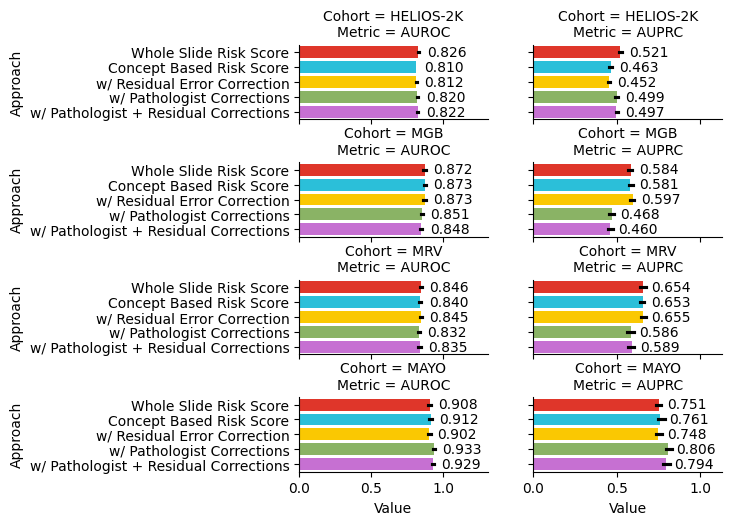

In [161]:
g = sns.FacetGrid(
    df_scoring_results,
    row="Cohort",
    row_order=[train_cohort] + validation_cohorts,
    col="Metric",
    height=1.25,
    aspect=2,
    margin_titles=False,
    sharex="col",
    sharey="row",
)

# Plot bars with error bars for each model and cohort
for (cohort, metric), ax in g.axes_dict.items():
    
    ax.set_title(f"Cohort = {cohort}" + "\n" + f"Metric = {metric}", fontsize=10)
    
    df_subset = df_scoring_results[(df_scoring_results["Cohort"] == cohort) & (df_scoring_results["Metric"] == metric)]
    sns.barplot(
        data=df_subset,
        y="Approach",
        x="Value",
        hue="Approach",
        ax=ax,
        palette=list(COLORS.values())[:len(APPROACHES)],
        saturation=1.0,
        estimator="median",
        errorbar=("ci", 95),
        err_kws={"color": "black"},
    )
    
    max_value = df_subset.groupby("Approach")["Value"].median().max()
    # baseline_score = df_results_baselines.loc[cohort, metric]
    
    # Add annotations indicating the median value for each bar.
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", label_type="edge", color="black", padding=6)
    
    # Add vertical line for random baseline.
    # ax.axvline(baseline_score, color="black", linestyle="--", label="Random Baseline")
    
    # Adjust x-axis limits to accommodate annotations and baseline line. Compute it as the maximum of the current limit and the maximum value plus some padding.
    ax.set_xlim(xmax=max(ax.get_xlim()[1], max_value * 1.4))
    
    # # Shift y-axis limit to place a random baseline annotation below the lowest bar.
    # ax.set_ylim(ymin=ax.get_ylim()[0] + 1.0)
    # ax.annotate(
    #     f"Random: {baseline_score:.3f}",
    #     xy=(baseline_score, ax.get_ylim()[0] - 0.5),
    #     xytext=(3, 0),
    #     textcoords="offset points",
    #     ha="left",
    #     va="center",
    #     color="black",
    # )

# for (cohort, metric), ax in g.axes_dict.items():
#     # Add annotation between top-2 models on each cohort and risk score type if they are significantly different based on Mann-Whitney U test.
#     pairs = [(model_order_by_cohort[cohort][i], model_order_by_cohort[cohort][j]) for i in range(2) for j in range(i + 1, 2)]
#     annotator = Annotator(ax, pairs, data=df_subset, x="Value", y="Approach", orient="h", hue="Approach", order=model_order_by_cohort[cohort])
#     annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
#     annotator.apply_and_annotate()
    

In [165]:
df_results_agg[["image_id", "cohort"] + list(APPROACHES.keys())[1:]].to_csv("output/data/risk_score/concept_risk_score.csv", index=False)

### Calibrate the Whole Slide Risk Score

In [247]:
y_prob.min()

np.float64(-0.13173658695047452)

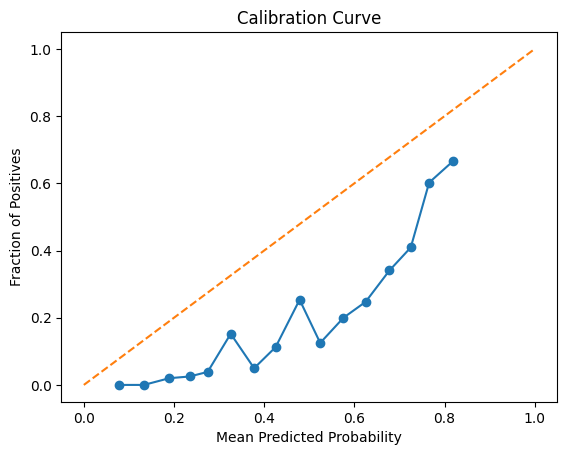

In [253]:
from sklearn.calibration import calibration_curve

y_true, y_prob = df_results_agg[df_results_agg["cohort"] == "HELIOS-2K"][[DEFAULT_SAMPLE_LABEL_COL, "concept_risk_score_path_correction"]].dropna().values.T

prob_true, prob_pred = calibration_curve(y_true, y_prob * 0.7 + 0.15, n_bins=20)

import matplotlib.pyplot as plt
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.show()